In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
import gc
from pathlib import Path
import netCDF4 as nc
from datetime import datetime
import re
from datetime import timedelta

In [2]:
gemlam_dir = "/results/forcing/atmospheric/GEM2.5/gemlam"
operational_dir = "/results/forcing/atmospheric/GEM2.5/operational"
time_fixed_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/TimeFixed"

gemlam_start = datetime(2007, 1, 3)
gemlam_end = datetime(2014, 9, 30)
ops_start = datetime(2014, 10, 1)
ops_end = datetime(2021, 12, 31)

years = range(2007, 2022)

fixed_filenames = {
    "gemlam_y2008m07d16.nc",
    "gemlam_y2008m07d17.nc",
    "gemlam_y2008m07d18.nc",
    "gemlam_y2008m07d19.nc",
    "gemlam_y2008m07d20.nc",
    "gemlam_y2008m07d21.nc",
    "gemlam_y2008m07d22.nc",
    "gemlam_y2008m07d23.nc",
    "gemlam_y2008m08d10.nc",
    "gemlam_y2008m08d11.nc",
    "gemlam_y2008m08d12.nc",
    "gemlam_y2012m10d04.nc"   
}

def get_file_date(filepath):
    filename = os.path.basename(filepath)
    match = re.search(r"_y(\d{4})m(\d{2})d(\d{2})", filename)
    if match is None:
        return None
    year, month, day = map(int, match.groups())
    return datetime(year, month, day)

all_gemlam_files = glob.glob(os.path.join(gemlam_dir, "*.nc"))
all_ops_files = glob.glob(os.path.join(operational_dir, "ops_y????m??d??.nc"))

selected_gemlam_files = {}

for filepath in all_gemlam_files:
    file_date = get_file_date(filepath)
    if file_date is not None and gemlam_start <= file_date <= gemlam_end:
        selected_gemlam_files[file_date] = filepath

for filename in fixed_filenames:
    fixed_filepath = os.path.join(time_fixed_dir, filename)
    if not os.path.exists(fixed_filepath):
        raise FileNotFoundError(f"Corrected file not found: {fixed_filepath}")
    fixed_date = get_file_date(fixed_filepath)
    if fixed_date is None:
        raise ValueError(f"Could not extract date from: {fixed_filepath}")
    selected_gemlam_files[fixed_date] = fixed_filepath

selected_ops_files = {}

for filepath in all_ops_files:
    file_date = get_file_date(filepath)
    if file_date is not None and ops_start <= file_date <= ops_end:
        selected_ops_files[file_date] = filepath

all_selected_files = {**selected_gemlam_files, **selected_ops_files}

hrdps_files_by_year = {}

for year in years:
    files = [filepath for file_date, filepath in sorted(all_selected_files.items()) if file_date.year == year]
    if len(files) == 0:
        print(f"{year}: no files found")
        continue
    hrdps_files_by_year[year] = files
    print(year, ":", files[0], "to", files[-1], f"({len(files)} files)")

2007 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d03.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m12d31.nc (363 files)
2008 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m12d31.nc (366 files)
2009 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m12d31.nc (365 files)
2010 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m12d31.nc (365 files)
2011 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m12d31.nc (365 files)
2012 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m12d31.nc (366 files)
2013 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2013m01d01.nc to /results/forc

In [3]:
# Loading datasets

weights_pre_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
weights_post_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_22sep11onward.nc"
weights_ops_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-ops_201702.nc"

mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"

ds_weights_pre = xr.open_dataset(weights_pre_file).load()
ds_weights_post = xr.open_dataset(weights_post_file).load()
ds_weights_ops = xr.open_dataset(weights_ops_file).load()


with xr.open_dataset(mesh_mask_file) as ds_mesh:
    nemo_lat = ds_mesh["nav_lat"].load()
    nemo_lon = ds_mesh["nav_lon"].load()

In [4]:
# Converts hourly HRDPS Shortwave Radiation from the 266 × 256 HRDPS grid to the 898 × 398 NEMO grid

transition_time_2011 = pd.Timestamp("2011-09-22 00:00:00")
transition_time_2014 = pd.Timestamp("2014-10-01 00:00:00")

def interpolate_solar_with_weights(solar, ds_weights):
    solar = solar.transpose("time_counter", "y", "x")

    n_time = solar.sizes["time_counter"]
    source_shape = (solar.sizes["y"], solar.sizes["x"])
    n_source_cells = source_shape[0] * source_shape[1]

    source_values = (solar.values.reshape(n_time, n_source_cells).astype(np.float32))
    target_shape = ds_weights["src01"].shape

    interpolated = np.zeros((n_time, target_shape[0], target_shape[1]),dtype=np.float32)

    for n in range(1, 5):

        source_index = (ds_weights[f"src{n:02d}"].values.astype(np.int64) - 1)
        weight = (ds_weights[f"wgt{n:02d}"].values.astype(np.float32))

        interpolated += (source_values[:, source_index] *weight[None, :, :])

    solar_nemo = xr.DataArray(
        interpolated,
        dims=("time_counter", "y", "x"),
        coords={
            "time_counter": solar["time_counter"],
            "nav_lat": (("y", "x"), nemo_lat.values),
            "nav_lon": (("y", "x"), nemo_lon.values),
        },
        name="solar"
    )

    solar_nemo.attrs = solar.attrs.copy()
    solar_nemo.attrs["grid"] = "SalishSeaCast NEMO grid"
    solar_nemo.attrs["interpolation"] = (
        "Four-source weighted HRDPS-to-NEMO interpolation"
    )

    return solar_nemo

In [5]:
# Open file and interpolate using date-dependent weights

def extract_and_interpolate_hourly_solar(file):

    with xr.open_dataset(file) as ds:
        solar = ds["solar"].sortby("time_counter")
        time_index = solar.get_index("time_counter")
        if time_index.has_duplicates:
            unique_mask = ~time_index.duplicated()
            solar = solar.isel(time_counter=unique_mask)

        solar = solar.load()


    times = pd.to_datetime(solar["time_counter"].values)
    
    pre_2011 = times < transition_time_2011
    gemlam_post_2011 = (
        (times >= transition_time_2011) &
        (times < transition_time_2014)
    )
    ops_2014_onward = times >= transition_time_2014

    pieces = []

    if pre_2011.any():
        solar_pre = solar.isel(time_counter=np.where(pre_2011)[0])
        interpolated_pre = interpolate_solar_with_weights(solar_pre,ds_weights_pre)
        pieces.append(interpolated_pre)


    if gemlam_post_2011.any():
        solar_post = solar.isel(time_counter=np.where(gemlam_post_2011)[0])
        interpolated_post = interpolate_solar_with_weights( solar_post,ds_weights_post )
        pieces.append(interpolated_post)


    if ops_2014_onward.any():
        solar_ops = solar.isel(time_counter=np.where(ops_2014_onward)[0])
        interpolated_ops = interpolate_solar_with_weights(solar_ops,ds_weights_ops)
        pieces.append(interpolated_ops)


    solar_nemo = xr.concat(pieces,dim="time_counter").sortby("time_counter")
    return solar_nemo

In [6]:
sample_pre_file = hrdps_files_by_year[2008][0]
solar_nemo_pre = extract_and_interpolate_hourly_solar(sample_pre_file)

print("Shape:", solar_nemo_pre.shape)
print("Time range:",solar_nemo_pre.time_counter.values[0],"to",solar_nemo_pre.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2008-01-01T00:00:00.000000000 to 2008-01-01T23:00:00.000000000


In [7]:
sample_post_file = hrdps_files_by_year[2012][0]
solar_nemo_post = extract_and_interpolate_hourly_solar(sample_post_file)

print("Shape:", solar_nemo_post.shape)
print("Time range:",solar_nemo_post.time_counter.values[0],"to",solar_nemo_post.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2012-01-01T00:00:00.000000000 to 2012-01-01T23:00:00.000000000


In [8]:
sample_post_file = hrdps_files_by_year[2015][0]
solar_nemo_post = extract_and_interpolate_hourly_solar(sample_post_file)

print("Shape:", solar_nemo_post.shape)
print("Time range:",solar_nemo_post.time_counter.values[0],"to",solar_nemo_post.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2015-01-01T00:00:00.000000000 to 2015-01-01T23:00:00.000000000


In [9]:
sample_post_file = hrdps_files_by_year[2021][-1]
solar_nemo_post = extract_and_interpolate_hourly_solar(sample_post_file)

print("Shape:", solar_nemo_post.shape)
print("Time range:",solar_nemo_post.time_counter.values[0],"to",solar_nemo_post.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2021-12-31T00:00:00.000000000 to 2021-12-31T23:00:00.000000000


In [10]:
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    water_mask = (ds_mesh["tmask"].isel(t=0, z=0).load().values.astype(bool))
    nemo_lat_2d = ds_mesh["nav_lat"].load().values
    nemo_lon_2d = ds_mesh["nav_lon"].load().values
nemo_j, nemo_i = np.where(water_mask)
water_flat_indices = np.flatnonzero(water_mask.reshape(-1))
nemo_water_lat = nemo_lat_2d[water_mask]
nemo_water_lon = nemo_lon_2d[water_mask]
n_water = len(water_flat_indices)
print("NEMO grid shape:", water_mask.shape)
print("Number of surface water cells:", n_water)

NEMO grid shape: (898, 398)
Number of surface water cells: 81383


In [11]:
def process_daily_file_to_3h_water(file):
    solar_nemo_hourly = extract_and_interpolate_hourly_solar(file)
    n_time = solar_nemo_hourly.sizes["time_counter"]

    solar_water_values = (solar_nemo_hourly.values.reshape(n_time, -1)[:, water_flat_indices].astype(np.float32))
    solar_water_hourly = xr.DataArray(solar_water_values,dims=("time_counter", "water_cell"),coords={
            "time_counter": solar_nemo_hourly["time_counter"].values,
            "water_cell": np.arange(n_water, dtype=np.int32),},name="solar",attrs=solar_nemo_hourly.attrs,)

    solar_water_3h = solar_water_hourly.resample(time_counter="3h",label="left",closed="left",origin="start_day",).mean()
    return solar_water_3h.load()

In [12]:
# # Run only once
# output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h"
# os.makedirs(output_dir, exist_ok=True)

# years = list(range(2007, 2022))
# hrdps_nemo_processed_files = []

# for year in years:
#     files = hrdps_files_by_year[year]

#     print(f"\nProcessing {year}: {len(files)} daily files")

#     daily_3h_results = []

#     for file_number, file in enumerate(files, start=1):

#         daily_3h = process_daily_file_to_3h_water(file)
#         daily_3h_results.append(daily_3h)

#         if (
#             file_number == 1
#             or file_number % 25 == 0
#             or file_number == len(files)
#         ):
#             print(f"{year}: processed {file_number}/{len(files)} files")

#     solar_year = xr.concat(
#         daily_3h_results,
#         dim="time_counter"
#     ).sortby("time_counter")

#     time_index = solar_year.get_index("time_counter")

#     if time_index.has_duplicates:
#         solar_year = solar_year.isel(
#             time_counter=~time_index.duplicated()
#         )

#     ds_year = solar_year.to_dataset(name="solar")

#     ds_year = ds_year.assign_coords(
#         nemo_j=("water_cell", nemo_j.astype(np.int32)),
#         nemo_i=("water_cell", nemo_i.astype(np.int32)),
#         nav_lat=("water_cell", nemo_water_lat.astype(np.float32)),
#         nav_lon=("water_cell", nemo_water_lon.astype(np.float32)),
#     )

#     ds_year.attrs["description"] = (
#         "Raw hourly HRDPS solar interpolated onto NEMO surface water cells, "
#         "using date-dependent HRDPS-to-NEMO interpolation weights, then "
#         "resampled to three-hourly means."
#     )

#     output_file = f"{output_dir}/HRDPS_NEMO_{year}_solar_3h.nc"

#     # Remove old file before regenerating it
#     if os.path.exists(output_file):
#         print("Removing existing file:", output_file)
#         os.remove(output_file)

#     encoding = {
#         "solar": {
#             "dtype": "float32",
#             "zlib": True,
#             "complevel": 4,
#         }
#     }

#     ds_year.to_netcdf(
#         output_file,
#         engine="netcdf4",
#         encoding=encoding,
#     )

#     hrdps_nemo_processed_files.append(output_file)

#     print("Saved:", output_file)
#     print("Shape:", ds_year["solar"].shape)
#     print(
#         "Time range:",
#         ds_year.time_counter.values[0],
#         "to",
#         ds_year.time_counter.values[-1],
#     )

#     del daily_3h_results
#     del solar_year
#     del ds_year

#     gc.collect()

In [13]:
hrdps_nemo_files = sorted(glob.glob("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h/HRDPS_NEMO_*_solar_3h.nc"))
ds_hrdps_nemo = xr.open_mfdataset(hrdps_nemo_files, combine="by_coords")
ds_hrdps_nemo = ds_hrdps_nemo.sortby("time_counter")

print(ds_hrdps_nemo)
print("Number of files:", len(hrdps_nemo_files))
print("First time:", ds_hrdps_nemo.time_counter.values[0])
print("Last time: ", ds_hrdps_nemo.time_counter.values[-1])
print("Shape:", ds_hrdps_nemo["solar"].shape)

<xarray.Dataset> Size: 14GB
Dimensions:       (time_counter: 43816, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 351kB 2007-01-03 ... 2021-12-...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nemo_i        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lat       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lon       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
Data variables:
    solar         (time_counter, water_cell) float32 14GB dask.array<chunksize=(363, 10173), meta=np.ndarray>
Attributes:
    description:  Raw hourly HRDPS solar interpolated onto NEMO surface water...
Number of files: 15
First time: 2007-01-03T00:00:00.000000000
Last time:  2021-12-31T21:00:00.000000000
Shape: (43816, 81383)


In [14]:
train_years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
validation_years = [2007, 2008, 2009]
test_years = [2019, 2020, 2021]

In [15]:
ds_hrdps_train = ds_hrdps_nemo.sel(time_counter=ds_hrdps_nemo.time_counter.dt.year.isin(train_years))
ds_hrdps_val = ds_hrdps_nemo.sel(time_counter=ds_hrdps_nemo.time_counter.dt.year.isin(validation_years))
ds_hrdps_test = ds_hrdps_nemo.sel(time_counter=ds_hrdps_nemo.time_counter.dt.year.isin(test_years))

In [16]:
canrcm_years = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
canrcm_rsds_files = []

for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_rsds.nc"))
    canrcm_rsds_files.append(matches[0])

print("CanRCM files:")
for file in canrcm_rsds_files:
    print(file)

CanRCM files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201301_201312_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201401_201412_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201501_201512_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201601_201612_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201701_201712_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201801_201812_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201901_201912_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_202001_202012_3h_

In [17]:
ds_canrcm = xr.open_mfdataset(canrcm_rsds_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
shifted_time = np.array([time_value - timedelta(hours=3)for time_value in ds_canrcm["time"].values])
ds_canrcm = ds_canrcm.assign_coords(time=("time", shifted_time))

print(ds_canrcm)
print("First timestamp:", ds_canrcm.time.values[0])
print("Last timestamp: ", ds_canrcm.time.values[-1])

/tmp/ipykernel_4040004/1216602351.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_rsds_files,combine="by_coords")


<xarray.Dataset> Size: 20GB
Dimensions:       (time: 43800, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 350kB 2007-01-01 00:00:00 ... 2021-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 701kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 44kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    rsds          (time, rlat, rlon) float32 20GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                  

In [18]:
nemo_water_lat = ds_hrdps_nemo["nav_lat"].values
nemo_water_lon = ds_hrdps_nemo["nav_lon"].values

nemo_water_lon_normalized = ((nemo_water_lon + 180) % 360) - 180

lat_min = float(np.nanmin(nemo_water_lat))
lat_max = float(np.nanmax(nemo_water_lat))

lon_min = float(np.nanmin(nemo_water_lon_normalized))
lon_max = float(np.nanmax(nemo_water_lon_normalized))

print("NEMO latitude range:", lat_min, "to", lat_max)
print("NEMO longitude range:", lon_min, "to", lon_max)

NEMO latitude range: 47.06300735473633 to 50.92766571044922
NEMO longitude range: -126.14797973632812 to -122.22117614746094


In [19]:
lat_canrcm = ds_canrcm["lat"]
lon_canrcm = ds_canrcm["lon"]

lon_canrcm_normalized = ((lon_canrcm + 180) % 360) - 180
canrcm_region_mask = ((lat_canrcm >= lat_min)& (lat_canrcm <= lat_max)
                      & (lon_canrcm_normalized >= lon_min) & (lon_canrcm_normalized <= lon_max))

rlat_indices, rlon_indices = np.where(canrcm_region_mask.values)

rlat_min = rlat_indices.min()
rlat_max = rlat_indices.max()

rlon_min = rlon_indices.min()
rlon_max = rlon_indices.max()

print("CanRCM rlat indices:", rlat_min, "to", rlat_max)
print("CanRCM rlon indices:", rlon_min, "to", rlon_max)

ds_canrcm_cut = (ds_canrcm[["rsds"]].isel(rlat=slice(rlat_min, rlat_max + 1),rlon=slice(rlon_min, rlon_max + 1)))
print(ds_canrcm_cut)

CanRCM rlat indices: 171 to 190
CanRCM rlon indices: 91 to 107
<xarray.Dataset> Size: 60MB
Dimensions:  (time: 43800, rlat: 20, rlon: 17)
Coordinates:
  * time     (time) object 350kB 2007-01-01 00:00:00 ... 2021-12-31 21:00:00
  * rlat     (rlat) float64 160B 2.51 2.73 2.95 3.17 ... 6.03 6.25 6.47 6.69
  * rlon     (rlon) float64 136B -19.25 -19.03 -18.81 ... -16.17 -15.95 -15.73
    lon      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
    lat      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
Data variables:
    rsds     (time, rlat, rlon) float32 60MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization

In [20]:
ds_canrcm_train = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(train_years))
ds_canrcm_val = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(validation_years))
ds_canrcm_test = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(test_years))

In [21]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")
    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")


def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = np.array([time_to_string(t)for t in ds_canrcm_split["time"].values])
    hrdps_times = np.array([time_to_string(t)for t in ds_hrdps_split["time_counter"].values])
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    return ds_canrcm_aligned, ds_hrdps_aligned

In [22]:
canrcm_times = np.array([time_to_string(time) for time in ds_canrcm_cut["time"].values])
hrdps_times = np.array([time_to_string(time) for time in ds_hrdps_nemo["time_counter"].values])

canrcm_not_in_hrdps = np.setdiff1d(canrcm_times, hrdps_times)
hrdps_not_in_canrcm = np.setdiff1d(hrdps_times, canrcm_times)

print("CanRCM timestamps not in HRDPS:", len(canrcm_not_in_hrdps))
print(canrcm_not_in_hrdps)

print("\nHRDPS timestamps not in CanRCM:", len(hrdps_not_in_canrcm))
print(hrdps_not_in_canrcm)

CanRCM timestamps not in HRDPS: 16
['2007-01-01 00:00:00' '2007-01-01 03:00:00' '2007-01-01 06:00:00'
 '2007-01-01 09:00:00' '2007-01-01 12:00:00' '2007-01-01 15:00:00'
 '2007-01-01 18:00:00' '2007-01-01 21:00:00' '2007-01-02 00:00:00'
 '2007-01-02 03:00:00' '2007-01-02 06:00:00' '2007-01-02 09:00:00'
 '2007-01-02 12:00:00' '2007-01-02 15:00:00' '2007-01-02 18:00:00'
 '2007-01-02 21:00:00']

HRDPS timestamps not in CanRCM: 32
['2008-02-29 00:00:00' '2008-02-29 03:00:00' '2008-02-29 06:00:00'
 '2008-02-29 09:00:00' '2008-02-29 12:00:00' '2008-02-29 15:00:00'
 '2008-02-29 18:00:00' '2008-02-29 21:00:00' '2012-02-29 00:00:00'
 '2012-02-29 03:00:00' '2012-02-29 06:00:00' '2012-02-29 09:00:00'
 '2012-02-29 12:00:00' '2012-02-29 15:00:00' '2012-02-29 18:00:00'
 '2012-02-29 21:00:00' '2016-02-29 00:00:00' '2016-02-29 03:00:00'
 '2016-02-29 06:00:00' '2016-02-29 09:00:00' '2016-02-29 12:00:00'
 '2016-02-29 15:00:00' '2016-02-29 18:00:00' '2016-02-29 21:00:00'
 '2020-02-29 00:00:00' '2020-02-29

In [23]:
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)

In [24]:
print("Validation:")
print("HRDPS:", ds_hrdps_val.sizes["time_counter"])
print("CanRCM:", ds_canrcm_val.sizes["time"])
print("Training:")
print("HRDPS:", ds_hrdps_train.sizes["time_counter"])
print("CanRCM:", ds_canrcm_train.sizes["time"])
print("Testing:")
print("HRDPS:", ds_hrdps_test.sizes["time_counter"])
print("CanRCM:", ds_canrcm_test.sizes["time"])

Validation:
HRDPS: 8744
CanRCM: 8744
Training:
HRDPS: 26280
CanRCM: 26280
Testing:
HRDPS: 8760
CanRCM: 8760


In [25]:
X_hrdps_train_raw = (ds_hrdps_train["solar"].values.astype(np.float32))
X_hrdps_val_raw = (ds_hrdps_val["solar"].values.astype(np.float32))
X_hrdps_test_raw = (ds_hrdps_test["solar"].values.astype(np.float32))

print("Raw HRDPS-NEMO train:", X_hrdps_train_raw.shape)
print("Raw HRDPS-NEMO val:  ", X_hrdps_val_raw.shape)
print("Raw HRDPS-NEMO test: ", X_hrdps_test_raw.shape)

Raw HRDPS-NEMO train: (26280, 81383)
Raw HRDPS-NEMO val:   (8744, 81383)
Raw HRDPS-NEMO test:  (8760, 81383)


In [26]:
valid_fraction_hrdps = np.isfinite(X_hrdps_train_raw).mean(axis=0)
valid_nemo_cols = valid_fraction_hrdps > 0.95

X_hrdps_train = X_hrdps_train_raw[:, valid_nemo_cols].copy()
X_hrdps_val = X_hrdps_val_raw[:, valid_nemo_cols].copy()
X_hrdps_test = X_hrdps_test_raw[:, valid_nemo_cols].copy()

hrdps_col_mean = np.nanmean(X_hrdps_train,axis=0)

if not np.all(np.isfinite(hrdps_col_mean)):
    raise ValueError(
        "At least one retained NEMO cell has a non-finite training mean."
    )


def fill_with_training_mean(X, training_mean):
    X = X.copy()
    rows, cols = np.where(~np.isfinite(X))
    X[rows, cols] = training_mean[cols]
    return X


X_hrdps_train = fill_with_training_mean(X_hrdps_train,hrdps_col_mean)
X_hrdps_val = fill_with_training_mean(X_hrdps_val,hrdps_col_mean)
X_hrdps_test = fill_with_training_mean(X_hrdps_test,hrdps_col_mean)

print("Valid NEMO cells:", valid_nemo_cols.sum())
print("Final HRDPS train:", X_hrdps_train.shape)
print("Final HRDPS val:  ", X_hrdps_val.shape)
print("Final HRDPS test: ", X_hrdps_test.shape)

Valid NEMO cells: 81383
Final HRDPS train: (26280, 81383)
Final HRDPS val:   (8744, 81383)
Final HRDPS test:  (8760, 81383)


In [27]:
valid_water_cell = (ds_hrdps_train["water_cell"].values[valid_nemo_cols])
valid_nemo_j = (ds_hrdps_train["nemo_j"].values[valid_nemo_cols])
valid_nemo_i = (ds_hrdps_train["nemo_i"].values[valid_nemo_cols])
valid_nemo_lat = (ds_hrdps_train["nav_lat"].values[valid_nemo_cols])
valid_nemo_lon = (ds_hrdps_train["nav_lon"].values[valid_nemo_cols])
print("Saved coordinate count:", len(valid_water_cell))

Saved coordinate count: 81383


In [28]:
def make_canrcm_matrix(da):
    da = da.transpose("time", "rlat", "rlon")
    n_time = da.sizes["time"]
    return (da.values.reshape(n_time, -1).astype(np.float32))

X_canrcm_train_raw = make_canrcm_matrix(ds_canrcm_train["rsds"])
X_canrcm_val_raw = make_canrcm_matrix(ds_canrcm_val["rsds"])
X_canrcm_test_raw = make_canrcm_matrix(ds_canrcm_test["rsds"])

print("Raw CanRCM train:", X_canrcm_train_raw.shape)
print("Raw CanRCM val:  ", X_canrcm_val_raw.shape)
print("Raw CanRCM test: ", X_canrcm_test_raw.shape)

Raw CanRCM train: (26280, 340)
Raw CanRCM val:   (8744, 340)
Raw CanRCM test:  (8760, 340)


In [29]:
valid_fraction_canrcm = np.isfinite(X_canrcm_train_raw).mean(axis=0)
valid_canrcm_cols = valid_fraction_canrcm > 0.95

X_canrcm_train = X_canrcm_train_raw[:,valid_canrcm_cols].copy()
X_canrcm_val = X_canrcm_val_raw[:,valid_canrcm_cols].copy()
X_canrcm_test = X_canrcm_test_raw[:,valid_canrcm_cols].copy()
canrcm_col_mean = np.nanmean(X_canrcm_train,axis=0)

if not np.all(np.isfinite(canrcm_col_mean)):
    raise ValueError(
        "At least one retained CanRCM cell has a non-finite training mean."
    )

X_canrcm_train = fill_with_training_mean(X_canrcm_train,canrcm_col_mean)
X_canrcm_val = fill_with_training_mean(X_canrcm_val,canrcm_col_mean)
X_canrcm_test = fill_with_training_mean(X_canrcm_test,canrcm_col_mean)
print("Final CanRCM train:", X_canrcm_train.shape)
print("Final CanRCM val:  ", X_canrcm_val.shape)
print("Final CanRCM test: ", X_canrcm_test.shape)

Final CanRCM train: (26280, 340)
Final CanRCM val:   (8744, 340)
Final CanRCM test:  (8760, 340)


In [30]:
hrdps_variance_threshold = 0.98
max_hrdps_pcs = min(300,X_hrdps_train.shape[0] - 1,X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs,svd_solver="randomized",random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)
threshold_indices = np.where(hrdps_cumulative_variance >= hrdps_variance_threshold)[0]
n_hrdps_pcs = threshold_indices[0] + 1
print("Selected HRDPS PCs:", n_hrdps_pcs)

Selected HRDPS PCs: 5


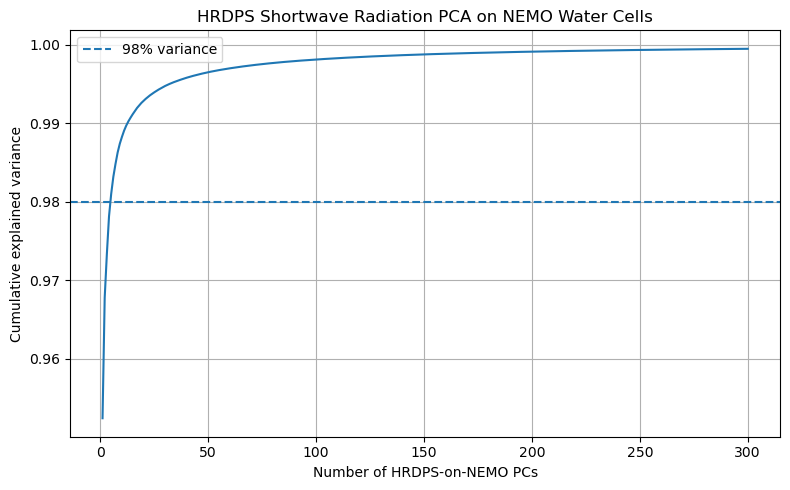

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1),hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold,linestyle="--",label="98% variance")
plt.xlabel("Number of HRDPS-on-NEMO PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS Shortwave Radiation PCA on NEMO Water Cells")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]

print("HRDPS train scores:", hrdps_train_scores.shape)
print("HRDPS val scores:  ", hrdps_val_scores.shape)
print("HRDPS test scores: ", hrdps_test_scores.shape)

HRDPS train scores: (26280, 5)
HRDPS val scores:   (8744, 5)
HRDPS test scores:  (8760, 5)


In [33]:
max_canrcm_pcs = min(100,X_canrcm_train.shape[0] - 1,X_canrcm_train.shape[1])
pca_canrcm = PCA(n_components=max_canrcm_pcs,svd_solver="randomized",random_state=0)
canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

In [34]:
canrcm_pc_candidates = range(1,max_canrcm_pcs + 1)
val_r2_scores = []
for n_canrcm_pcs_candidate in canrcm_pc_candidates:
    X_train_pc = canrcm_train_scores_all[:,:n_canrcm_pcs_candidate]
    X_val_pc = canrcm_val_scores_all[:,:n_canrcm_pcs_candidate]
    model = LinearRegression()
    model.fit(X_train_pc,hrdps_train_scores)
    hrdps_val_scores_pred_candidate = model.predict(X_val_pc)
    val_r2 = r2_score(hrdps_val_scores,hrdps_val_scores_pred_candidate,multioutput="variance_weighted")
    val_r2_scores.append(val_r2)
val_r2_scores = np.array(val_r2_scores)

best_index = np.nanargmax(val_r2_scores)
n_canrcm_pcs = list(canrcm_pc_candidates)[best_index]
best_val_r2 = val_r2_scores[best_index]

print("Best number of CanRCM PCs:", n_canrcm_pcs)

Best number of CanRCM PCs: 92


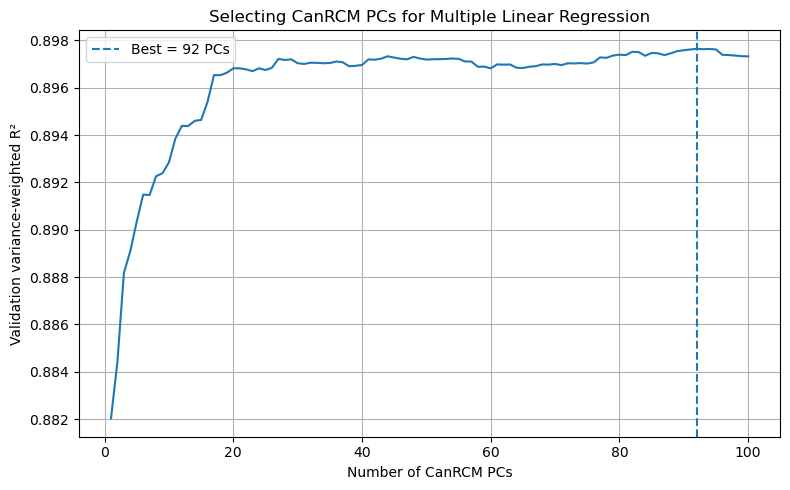

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(list(canrcm_pc_candidates),val_r2_scores)
plt.axvline(n_canrcm_pcs,linestyle="--",label=f"Best = {n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting CanRCM PCs for Multiple Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
X_train_pc_final = canrcm_train_scores_all[:,:n_canrcm_pcs]
X_val_pc_final = canrcm_val_scores_all[:,:n_canrcm_pcs]
X_test_pc_final = canrcm_test_scores_all[:,:n_canrcm_pcs]

In [37]:
lr_model = LinearRegression()
lr_model.fit(X_train_pc_final,hrdps_train_scores)

hrdps_train_scores_pred = lr_model.predict(X_train_pc_final)
hrdps_val_scores_pred = lr_model.predict(X_val_pc_final)
hrdps_test_scores_pred = lr_model.predict(X_test_pc_final)

print("Regression coefficient shape:", lr_model.coef_.shape)
print("Predicted HRDPS train scores:",hrdps_train_scores_pred.shape)
print("Predicted HRDPS validation scores:",hrdps_val_scores_pred.shape)
print("Predicted HRDPS test scores:",hrdps_test_scores_pred.shape)

Regression coefficient shape: (5, 92)
Predicted HRDPS train scores: (26280, 5)
Predicted HRDPS validation scores: (8744, 5)
Predicted HRDPS test scores: (8760, 5)


In [38]:
def inverse_from_selected_hrdps_pcs(scores, pca, n_pcs):
    reconstructed = np.dot(scores,pca.components_[:n_pcs, :])
    reconstructed = reconstructed + pca.mean_
    return reconstructed.astype(np.float32)

In [39]:
X_hrdps_val_pred = inverse_from_selected_hrdps_pcs(hrdps_val_scores_pred,pca_hrdps,n_hrdps_pcs)
X_hrdps_test_pred = inverse_from_selected_hrdps_pcs(hrdps_test_scores_pred,pca_hrdps,n_hrdps_pcs)

In [40]:
def calculate_metrics(actual, predicted, label):
    rmse = np.sqrt(mean_squared_error(actual.ravel(),predicted.ravel()))
    mae = mean_absolute_error(actual.ravel(),predicted.ravel())
    bias = np.mean(predicted - actual)
    r2 = r2_score(actual,predicted,multioutput="variance_weighted")
    actual_std = np.std(actual, ddof=0)
    normalized_rmse = rmse / actual_std
    print(f"\n{label}")
    print("RMSE:", rmse)
    print("MAE: ", mae)
    print("Bias:", bias)
    print("R^2:  ", r2)
    print("Actual standard deviation:", actual_std)
    print("Normalized RMSE:", normalized_rmse)
    print("Normalized RMSE (%):", normalized_rmse * 100)
    return {"RMSE": rmse,"MAE": mae,"Bias": bias,"R2": r2, "Normalized_RMSE": normalized_rmse,"Normalized_RMSE_percent": normalized_rmse * 100}

In [41]:
val_metrics = calculate_metrics(X_hrdps_val, X_hrdps_val_pred, "Validation metrics on NEMO water cells")
test_metrics = calculate_metrics(X_hrdps_test,X_hrdps_test_pred,"Test metrics on NEMO water cells")


Validation metrics on NEMO water cells
RMSE: 84.49794861600192
MAE:  48.89078903198242
Bias: -5.7438216
R^2:   0.8824794292449951
Actual standard deviation: 246.5461
Normalized RMSE: 0.3427267748795262
Normalized RMSE (%): 34.27267748795262

Test metrics on NEMO water cells
RMSE: 76.20977422548896
MAE:  44.042354583740234
Bias: 2.3100421
R^2:   0.901748776435852
Actual standard deviation: 243.20084
Normalized RMSE: 0.3133614810788306
Normalized RMSE (%): 31.336148107883062


In [42]:
def nemo_vector_to_map(vector):
    nemo_map = np.full(water_mask.shape,np.nan,dtype=np.float32)
    nemo_map[valid_nemo_j,valid_nemo_i] = vector
    return nemo_map

In [43]:
def plot_actual_predicted_error(time_index,X_actual,X_predicted,times):
    actual_map = nemo_vector_to_map(X_actual[time_index])
    predicted_map = nemo_vector_to_map(X_predicted[time_index])
    error_map = predicted_map - actual_map
    temp_min = np.nanmin(np.stack([actual_map, predicted_map]))
    temp_max = np.nanmax(np.stack([actual_map, predicted_map]))
    error_limit = np.nanmax(np.abs(error_map))
    timestamp = pd.Timestamp(times[time_index])
    fig, axes = plt.subplots(1,3,figsize=(12, 8))

    p0 = axes[0].pcolormesh(actual_map,shading="auto",vmin=temp_min,vmax=temp_max)
    axes[0].set_title(f"Actual HRDPS on NEMO Grid\n{timestamp}")
    plt.colorbar(p0,ax=axes[0],label="Shortwave Radiation")

    p1 = axes[1].pcolormesh(predicted_map,shading="auto",vmin=temp_min,vmax=temp_max )
    axes[1].set_title(f"Predicted PCA + MLR\n{timestamp}")
    plt.colorbar(p1,ax=axes[1],label="Temperture")

    p2 = axes[2].pcolormesh(error_map,shading="auto",cmap="RdBu_r",vmin=-error_limit,vmax=error_limit)
    axes[2].set_title(f"Predicted − Actual\n{timestamp}")
    plt.colorbar(p2,ax=axes[2],label="Error")

    for ax in axes:
        ax.set_xlabel("NEMO x index (i)")
        ax.set_ylabel("NEMO y index (j)")

    plt.tight_layout()
    plt.show()

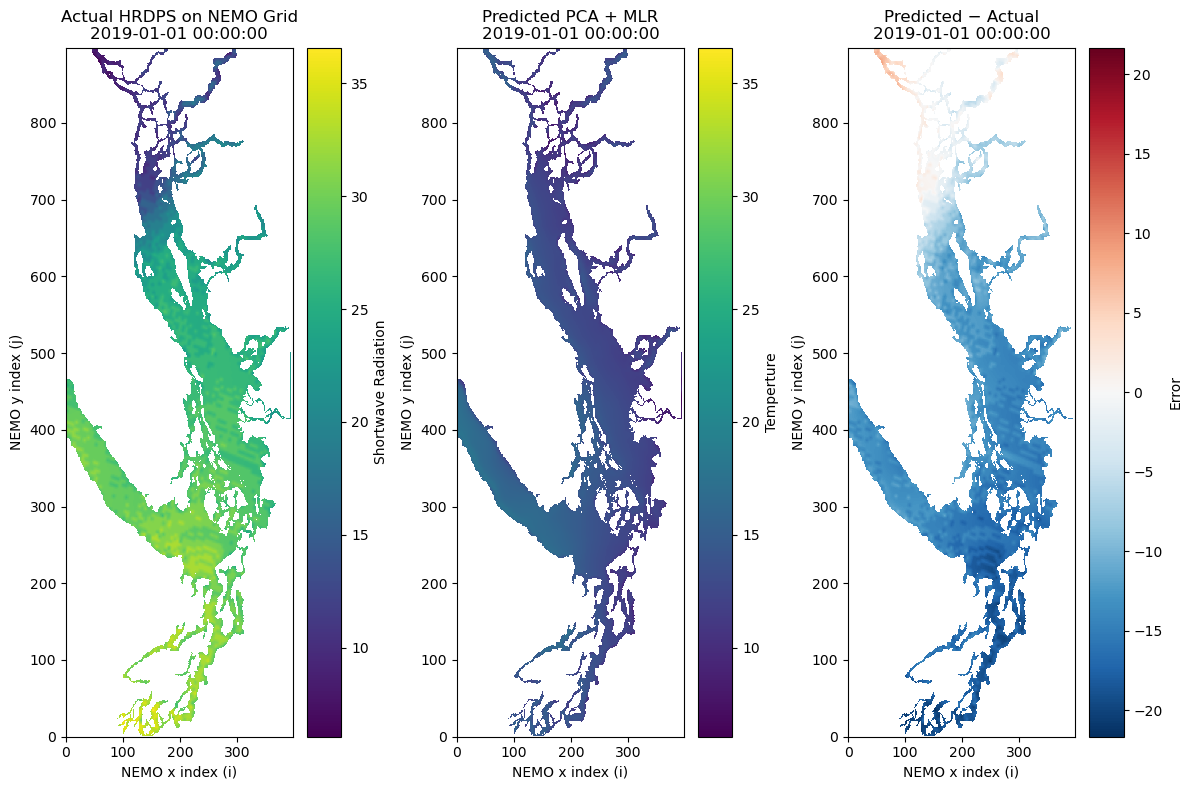

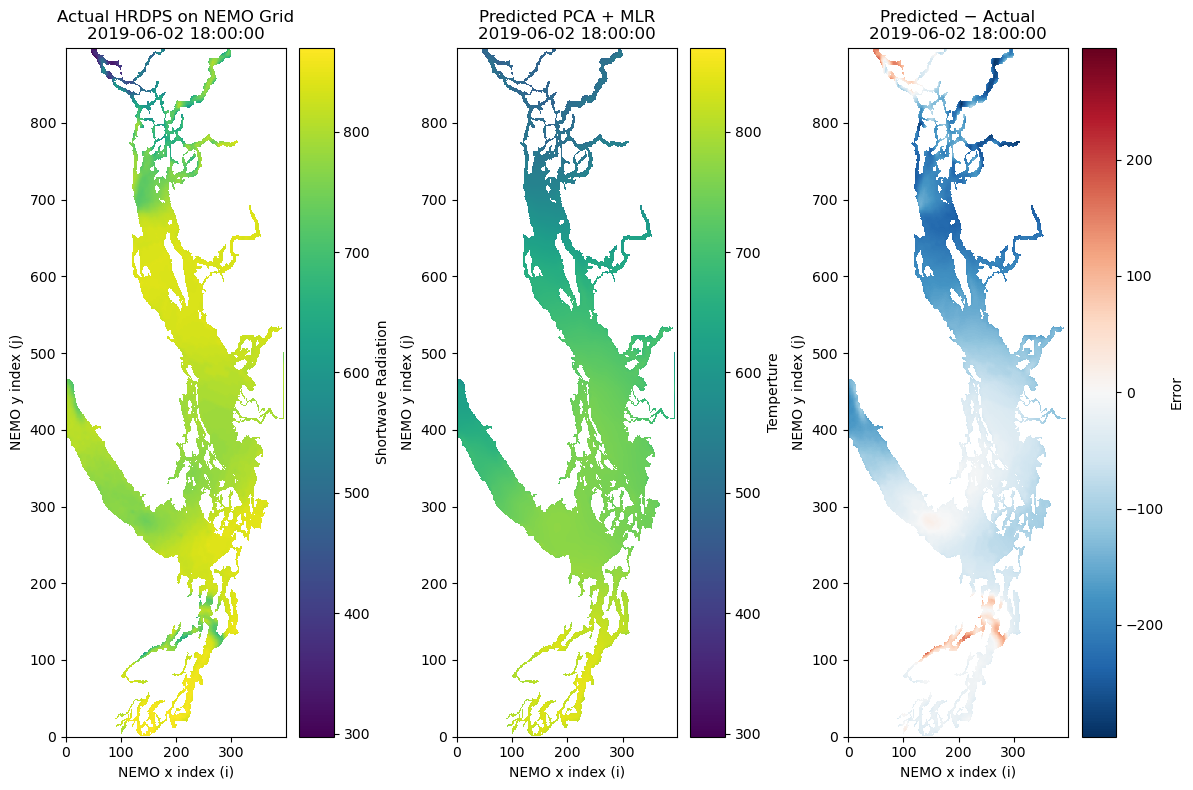

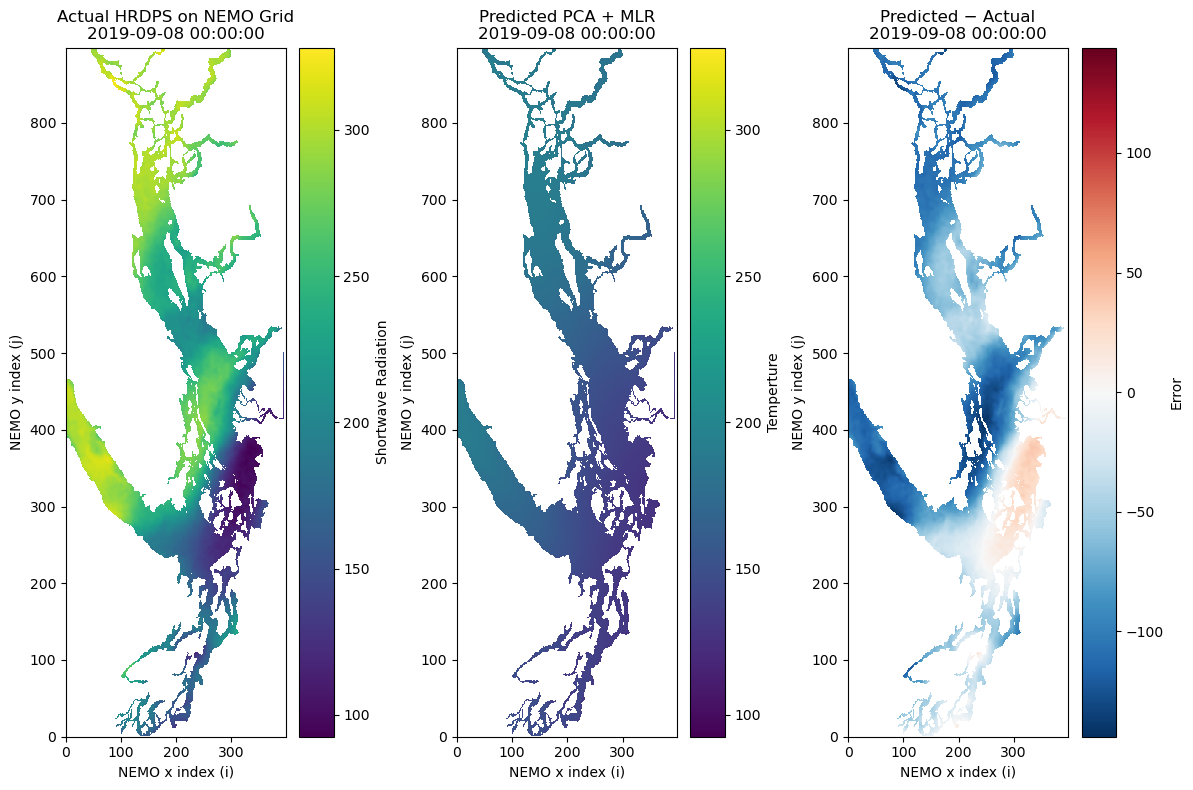

In [44]:
test_times = ds_hrdps_test["time_counter"].values

plot_actual_predicted_error(
    time_index=0,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred,
    times=test_times
)

plot_actual_predicted_error(
    time_index=1222,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred,
    times=test_times
)

plot_actual_predicted_error(
    time_index=2000,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred,
    times=test_times
)

In [45]:
def make_spatial_mean_timeseries(actual_matrix,predicted_matrix,times):
    actual_mean = np.mean(actual_matrix,axis=1)
    predicted_mean = np.mean(predicted_matrix,axis=1)
    timeseries = pd.DataFrame({"actual": actual_mean,"predicted": predicted_mean},index=pd.to_datetime(times))
    timeseries.index.name = "Date"
    return timeseries

In [46]:
val_times = ds_hrdps_val["time_counter"].values
test_times = ds_hrdps_test["time_counter"].values

shortwave_radiation_timeseries_val = make_spatial_mean_timeseries(
    actual_matrix=X_hrdps_val,
    predicted_matrix=X_hrdps_val_pred,
    times=val_times
)

shortwave_radiation_timeseries_test = make_spatial_mean_timeseries(
    actual_matrix=X_hrdps_test,
    predicted_matrix=X_hrdps_test_pred,
    times=test_times
)

print(shortwave_radiation_timeseries_val.head())
print()
print(shortwave_radiation_timeseries_val.tail())
print()
print(shortwave_radiation_timeseries_test.head())
print()
print(shortwave_radiation_timeseries_test.tail())

                      actual  predicted
Date                                   
2007-01-03 00:00:00  7.81371   9.654148
2007-01-03 03:00:00  0.00000   6.681275
2007-01-03 06:00:00  0.00000   6.681275
2007-01-03 09:00:00  0.00000   6.681275
2007-01-03 12:00:00  0.00000   6.681275

                        actual  predicted
Date                                     
2009-12-31 09:00:00   0.000000   6.681275
2009-12-31 12:00:00   0.000000   6.681275
2009-12-31 15:00:00   1.448060  14.189121
2009-12-31 18:00:00  26.914528  58.634991
2009-12-31 21:00:00  29.982525  43.951702

                        actual  predicted
Date                                     
2019-01-01 00:00:00  25.814341  13.347803
2019-01-01 03:00:00   0.000000   6.681275
2019-01-01 06:00:00   0.000000   6.681275
2019-01-01 09:00:00   0.000000   6.681275
2019-01-01 12:00:00   0.000000   6.681275

                         actual   predicted
Date                                       
2021-12-31 09:00:00    0.000000    6.6812

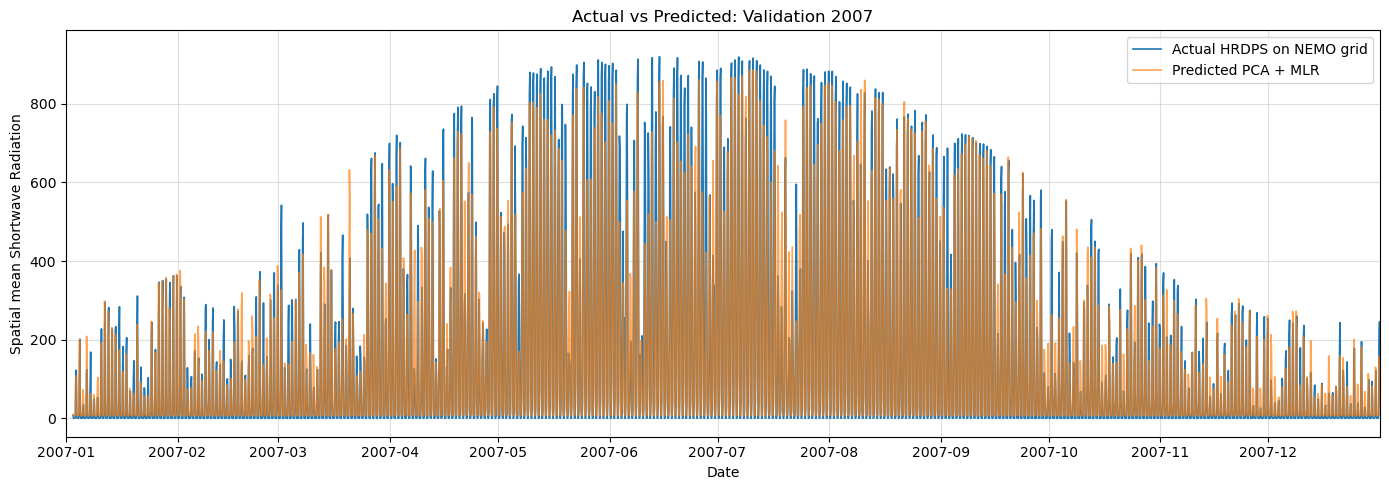

In [47]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(shortwave_radiation_timeseries_val.index,shortwave_radiation_timeseries_val["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(shortwave_radiation_timeseries_val.index,shortwave_radiation_timeseries_val["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2007-01-01"),pd.Timestamp("2007-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Shortwave Radiation")
ax.set_title("Actual vs Predicted: Validation 2007")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

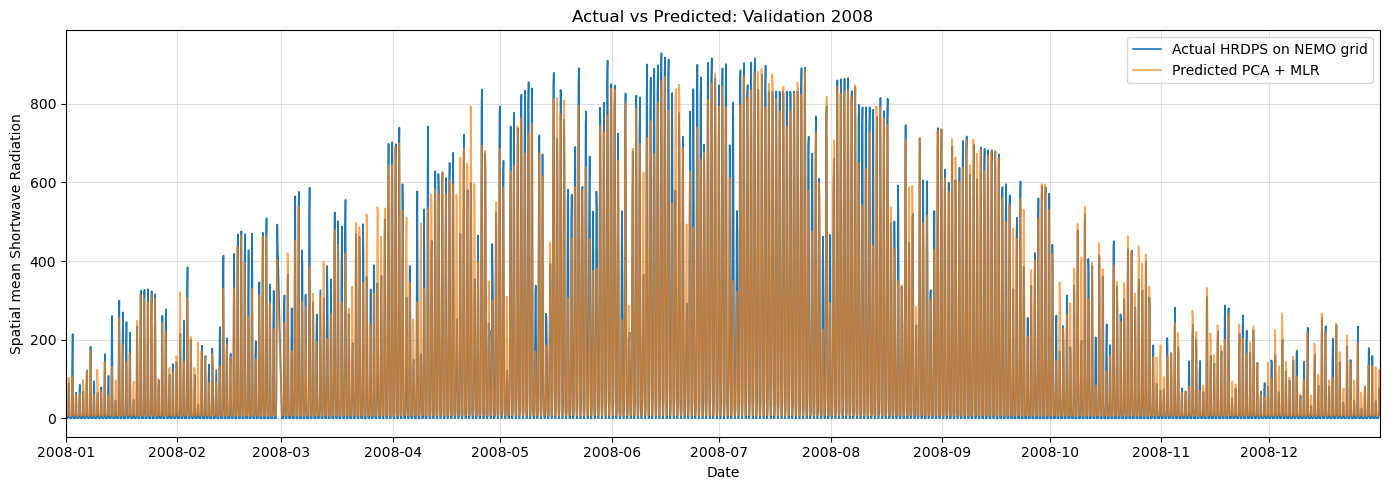

In [48]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(shortwave_radiation_timeseries_val.index,shortwave_radiation_timeseries_val["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(shortwave_radiation_timeseries_val.index,shortwave_radiation_timeseries_val["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2008-01-01"),pd.Timestamp("2008-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Shortwave Radiation")
ax.set_title("Actual vs Predicted: Validation 2008")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

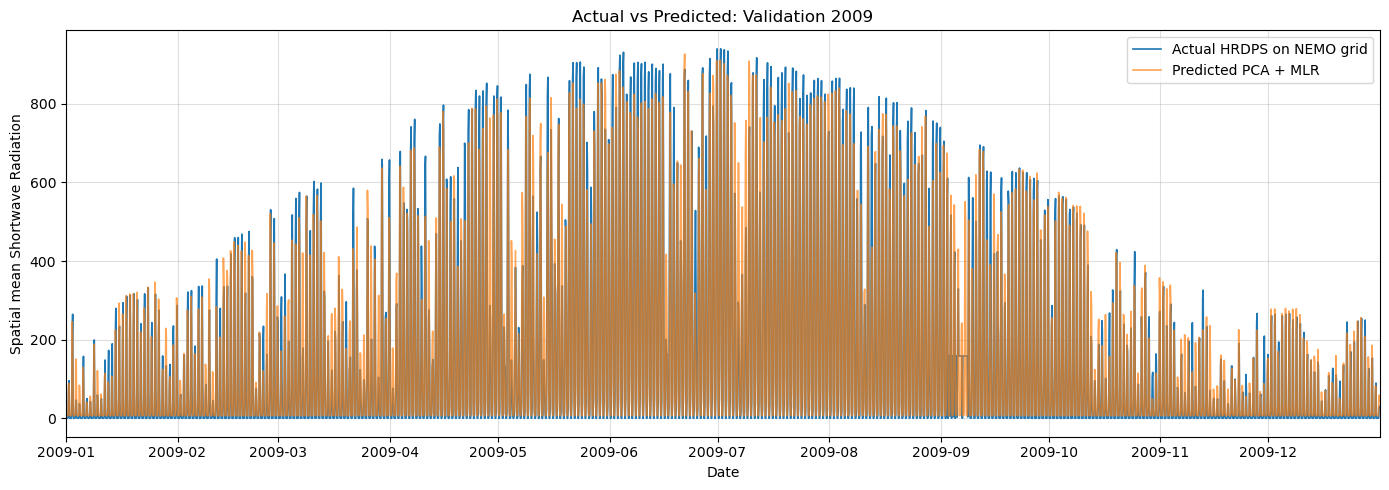

In [49]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(shortwave_radiation_timeseries_val.index,shortwave_radiation_timeseries_val["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(shortwave_radiation_timeseries_val.index,shortwave_radiation_timeseries_val["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2009-01-01"),pd.Timestamp("2009-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Shortwave Radiation")
ax.set_title("Actual vs Predicted: Validation 2009")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

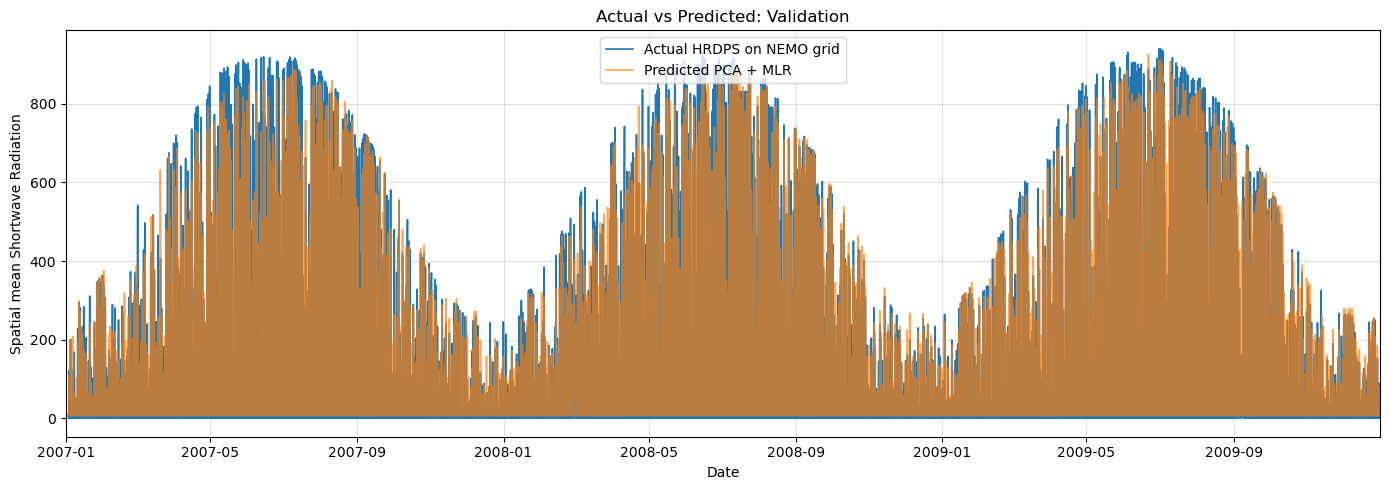

In [50]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(shortwave_radiation_timeseries_val.index,shortwave_radiation_timeseries_val["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(shortwave_radiation_timeseries_val.index,shortwave_radiation_timeseries_val["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2007-01-01"),pd.Timestamp("2009-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Shortwave Radiation")
ax.set_title("Actual vs Predicted: Validation")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

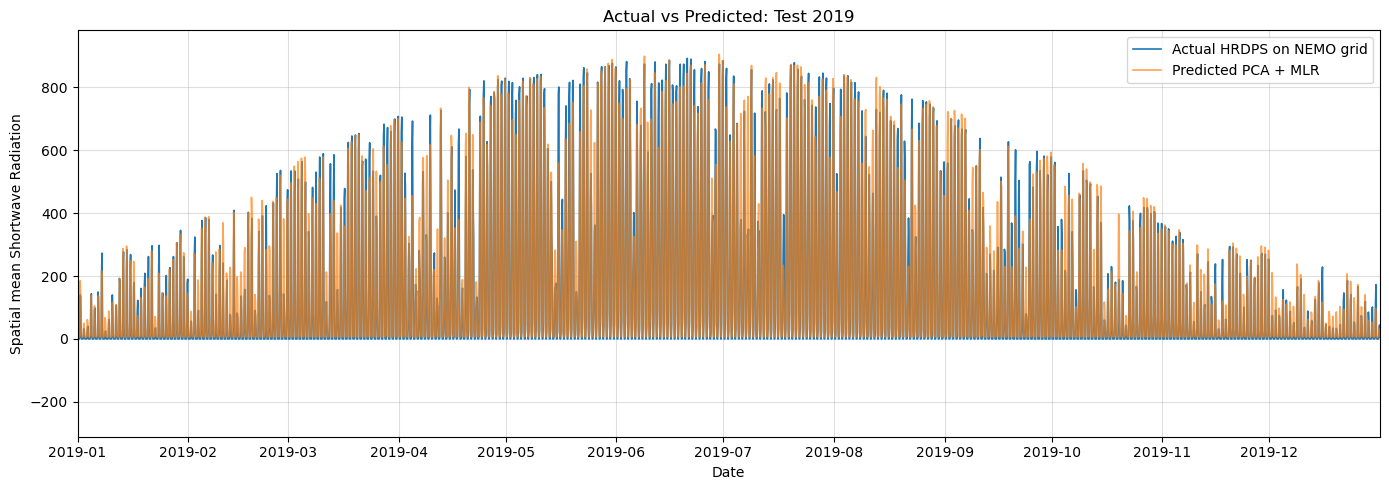

In [51]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(shortwave_radiation_timeseries_test.index, shortwave_radiation_timeseries_test["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
ax.plot(shortwave_radiation_timeseries_test.index, shortwave_radiation_timeseries_test["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)
ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Shortwave Radiation")
ax.set_title("Actual vs Predicted: Test 2019")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

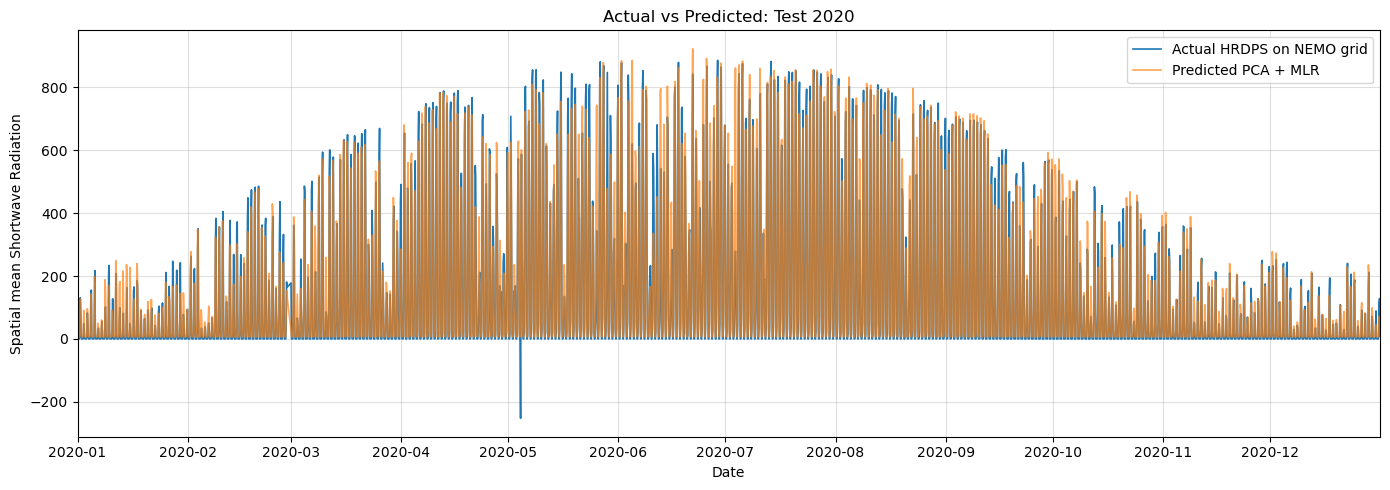

In [52]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(shortwave_radiation_timeseries_test.index, shortwave_radiation_timeseries_test["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
ax.plot(shortwave_radiation_timeseries_test.index, shortwave_radiation_timeseries_test["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)
ax.set_xlim(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Shortwave Radiation")
ax.set_title("Actual vs Predicted: Test 2020")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

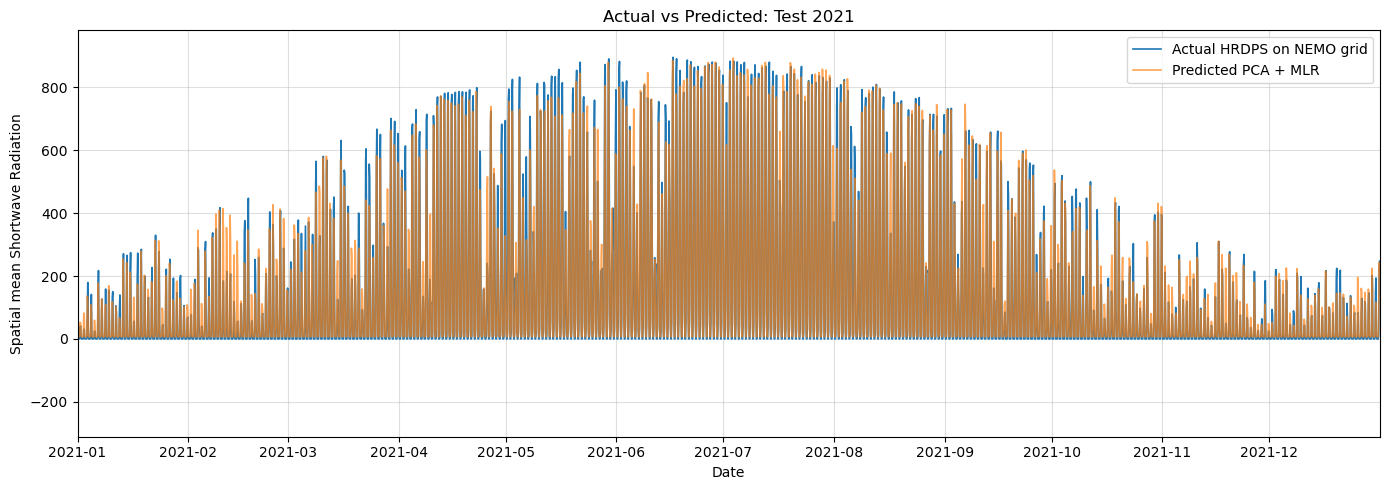

In [53]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(shortwave_radiation_timeseries_test.index, shortwave_radiation_timeseries_test["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
ax.plot(shortwave_radiation_timeseries_test.index, shortwave_radiation_timeseries_test["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)
ax.set_xlim(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Shortwave Radiation")
ax.set_title("Actual vs Predicted: Test 2021")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

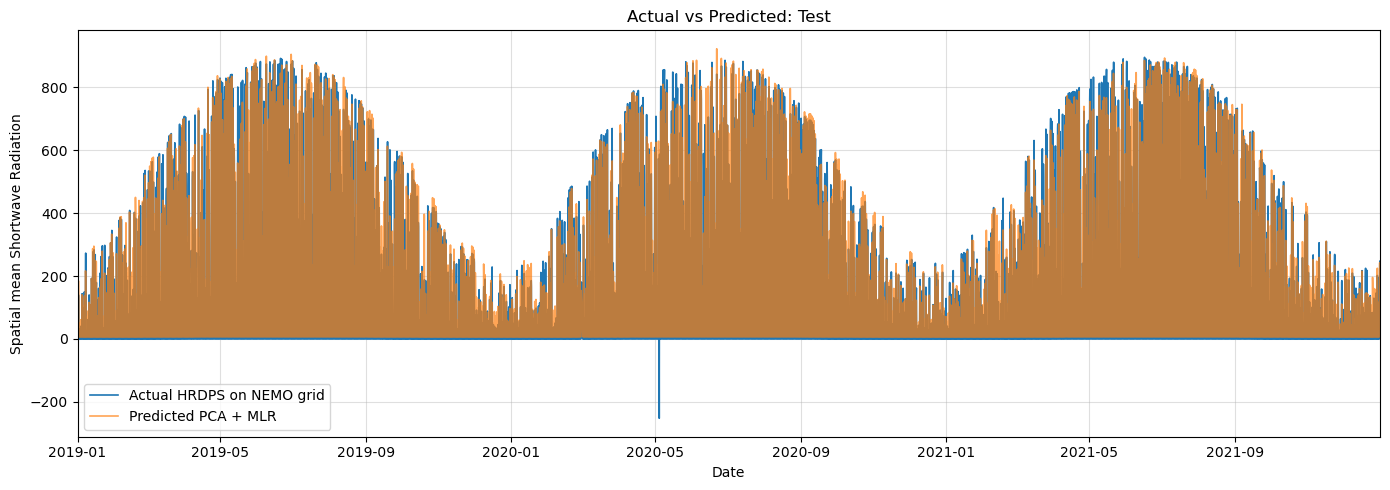

In [54]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(shortwave_radiation_timeseries_test.index, shortwave_radiation_timeseries_test["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
ax.plot(shortwave_radiation_timeseries_test.index, shortwave_radiation_timeseries_test["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)
ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2021-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Shortwave Radiation")
ax.set_title("Actual vs Predicted: Test")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [55]:
stations = {"Sand Heads": {"j": 426,"i": 293},
    "Halibut Bank": {"j": 503,"i": 261},
    "Sentry Shoal": {"j": 707,"i": 145}}

In [56]:
def find_station_column(station_j, station_i):
    matches = np.where((valid_nemo_j == station_j)& (valid_nemo_i == station_i))[0]
    return int(matches[0])

for station_name, station_info in stations.items():
    column = find_station_column(station_info["j"],station_info["i"])
    stations[station_name]["column"] = column
    print(station_name,"j =", station_info["j"],"i =", station_info["i"],"matrix column =", column)

Sand Heads j = 426 i = 293 matrix column = 44165
Halibut Bank j = 503 i = 261 matrix column = 53329
Sentry Shoal j = 707 i = 145 matrix column = 71870


In [57]:
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)
station_timeseries = {}
station_rmse = {}
station_normalized_rmse = {}

for station_name, station_info in stations.items():
    column = station_info["column"]

    actual = X_hrdps_test[:, column]
    predicted = X_hrdps_test_pred[:, column]

    station_df = pd.DataFrame({"actual": actual,"predicted": predicted},index=test_times)
    station_df.index.name = "Date"
    rmse = np.sqrt(mean_squared_error(station_df["actual"],station_df["predicted"]))
    actual_std = np.std(station_df["actual"],ddof=0)
    normalized_rmse = rmse / actual_std
    station_timeseries[station_name] = station_df
    station_rmse[station_name] = rmse
    station_normalized_rmse[station_name] = normalized_rmse
    print(f"{station_name} RMSE: {rmse:.4f} ")
    print(f"{station_name} Normalized RMSE: {normalized_rmse:.4f} ({normalized_rmse * 100:.2f}%)")

Sand Heads RMSE: 74.3141 
Sand Heads Normalized RMSE: 0.3022 (30.22%)
Halibut Bank RMSE: 75.7188 
Halibut Bank Normalized RMSE: 0.3116 (31.16%)
Sentry Shoal RMSE: 75.0277 
Sentry Shoal Normalized RMSE: 0.3127 (31.27%)


In [58]:
station_rmse_table = pd.DataFrame({"Station": list(station_rmse.keys()),"RMSE": list(station_rmse.values()),"Normalized_RMSE": list(station_normalized_rmse.values())})
station_rmse_table["Normalized_RMSE_Percent"] = station_rmse_table["Normalized_RMSE"] * 100
average_station_rmse = station_rmse_table["RMSE"].mean()
average_station_normalized_rmse = station_rmse_table["Normalized_RMSE"].mean()
print(station_rmse_table.to_string(index=False))
print(f"\nAverage RMSE across the three stations: {average_station_rmse:.4f}")
print(f"Average normalized RMSE across the three stations: {average_station_normalized_rmse:.4f} ({average_station_normalized_rmse * 100:.2f}%)")

     Station      RMSE  Normalized_RMSE  Normalized_RMSE_Percent
  Sand Heads 74.314064         0.302189                30.218948
Halibut Bank 75.718798         0.311618                31.161845
Sentry Shoal 75.027697         0.312669                31.266927

Average RMSE across the three stations: 75.0202
Average normalized RMSE across the three stations: 0.3088 (30.88%)


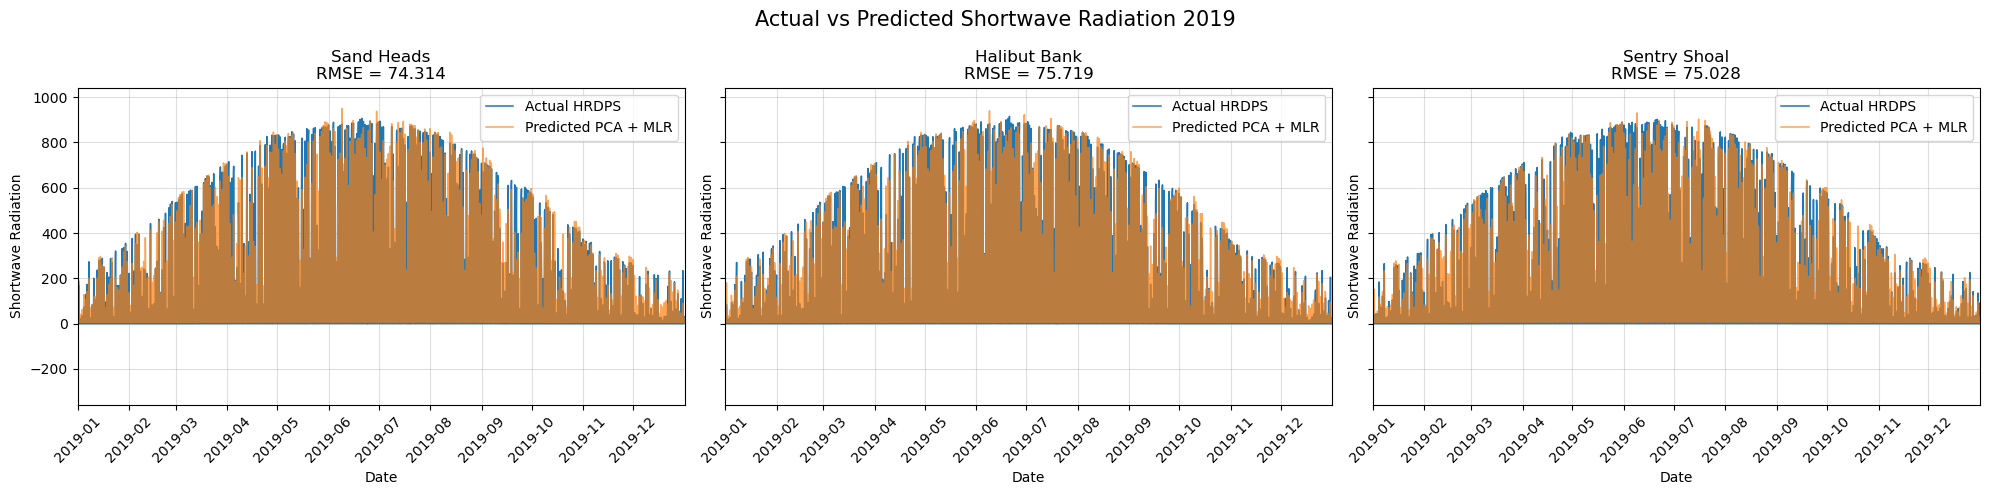

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, (station_name, station_df) in zip(axes, station_timeseries.items()):
    ax.plot(station_df.index, station_df["actual"], label="Actual HRDPS", linewidth=1.1)
    ax.plot(station_df.index, station_df["predicted"], label="Predicted PCA + MLR", linewidth=1.1, alpha=0.7)
    ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31 23:59:59"))
    ax.set_xlabel("Date")
    ax.set_ylabel("Shortwave Radiation")
    ax.set_title(f"{station_name}\nRMSE = {station_rmse[station_name]:.3f}")
    ax.legend()
    ax.grid(True, alpha=0.4)
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Actual vs Predicted Shortwave Radiation 2019", fontsize=15)

plt.tight_layout()
plt.show()

In [60]:
X_hrdps_train_pred = inverse_from_selected_hrdps_pcs(hrdps_train_scores_pred,pca_hrdps,n_hrdps_pcs)

print("Predicted training field shape:", X_hrdps_train_pred.shape)
print("Predicted validation field shape:", X_hrdps_val_pred.shape)
print("Predicted test field shape:", X_hrdps_test_pred.shape)

Predicted training field shape: (26280, 81383)
Predicted validation field shape: (8744, 81383)
Predicted test field shape: (8760, 81383)


In [61]:
train_times = pd.to_datetime(ds_hrdps_train["time_counter"].values)
val_times = pd.to_datetime(ds_hrdps_val["time_counter"].values)
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)

predicted_split_data = {
    "Validation": {"years": validation_years, "times": val_times, "values": X_hrdps_val_pred},
    "Training": {"years": train_years, "times": train_times, "values": X_hrdps_train_pred},
    "Test": {"years": test_years, "times": test_times, "values": X_hrdps_test_pred}
}

In [62]:
monthly_records = []

for split_name, split_data in predicted_split_data.items():
    predicted_spatial_mean = np.mean(split_data["values"],axis=1)
    predicted_timeseries = pd.DataFrame({"Predicted": predicted_spatial_mean},index=split_data["times"])
    predicted_timeseries.index.name = "Date"
    split_monthly_averages = predicted_timeseries.groupby([predicted_timeseries.index.year,predicted_timeseries.index.month])["Predicted"].mean()

    for (year, month), monthly_average in split_monthly_averages.items():
        monthly_records.append({"Year": int(year),"Month": int(month),"Predicted_Monthly_Average": float(monthly_average),"Split": split_name})

predicted_monthly_averages = pd.DataFrame(monthly_records)
predicted_monthly_averages = predicted_monthly_averages.sort_values(["Year","Month"]).reset_index(drop=True)

In [63]:
predicted_monthly_table = predicted_monthly_averages.pivot(index="Year",columns="Month",values="Predicted_Monthly_Average")
predicted_monthly_table = predicted_monthly_table.reindex(columns=range(1,13))
predicted_monthly_table.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

print("Predicted monthly average Shortwave Radiation table:")
print(predicted_monthly_table.round(2).to_string())

Predicted monthly average Shortwave Radiation table:
        Jan    Feb     Mar     Apr     May     Jun     Jul     Aug     Sep     Oct    Nov    Dec
Year                                                                                            
2007  54.35  61.99  104.47  174.85  250.79  237.46  277.06  260.18  176.85   89.31  57.41  36.46
2008  46.09  77.29  122.86  190.94  225.26  272.29  287.48  230.72  197.18   97.48  48.51  40.44
2009  55.77  91.01  122.67  206.74  242.30  299.73  313.25  248.24  178.91  105.57  49.60  50.60
2010  38.41  77.88  116.03  168.69  229.29  270.74  322.06  259.91  152.79  110.33  53.67  37.33
2011  42.26  83.81  107.86  183.12  221.99  273.45  271.53  269.93  178.55  101.09  53.30  45.38
2012  44.36  71.38  114.14  163.88  242.54  221.68  299.28  259.48  210.07  104.34  50.47  34.43
2013  46.14  65.67  127.69  191.22  235.11  267.35  333.28  233.58  165.90  125.75  55.31  40.86
2014  51.68  83.99  111.81  171.40  234.48  286.58  308.26  270.35  190.78

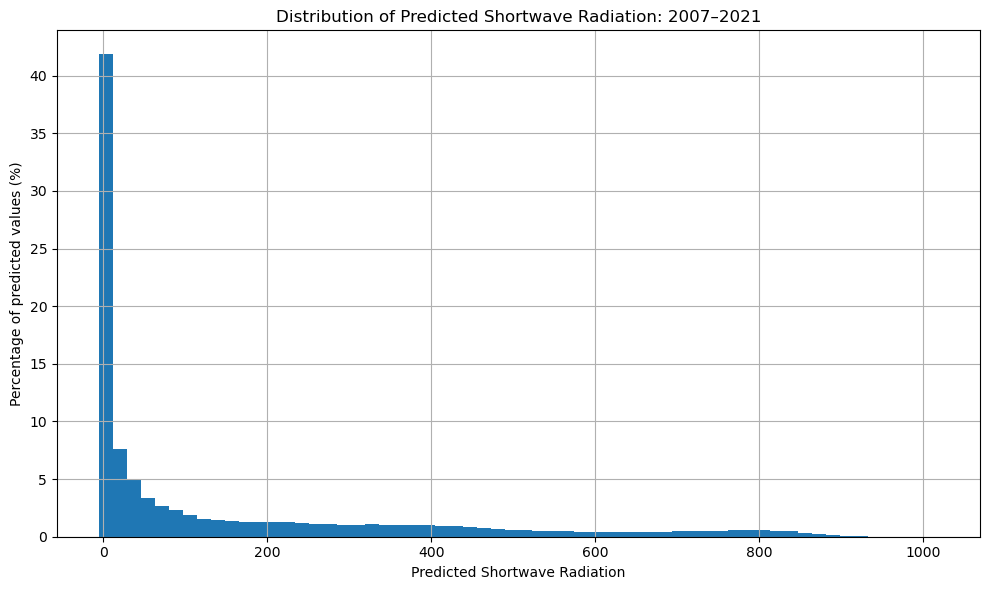

In [64]:
global_predicted_min = min(float(np.min(split_data["values"])) for split_data in predicted_split_data.values())
global_predicted_max = max(float(np.max(split_data["values"])) for split_data in predicted_split_data.values())
histogram_bins = np.linspace(global_predicted_min,global_predicted_max,61)
all_year_histogram_counts = np.zeros(len(histogram_bins) - 1,dtype=np.int64)

for split_data in predicted_split_data.values():
    split_counts, _ = np.histogram(split_data["values"],bins=histogram_bins)
    all_year_histogram_counts += split_counts

all_year_histogram_percentage = 100 * all_year_histogram_counts / all_year_histogram_counts.sum()

plt.figure(figsize=(10,6))
plt.stairs(all_year_histogram_percentage,histogram_bins,fill=True)
plt.xlabel("Predicted Shortwave Radiation")
plt.ylabel("Percentage of predicted values (%)")
plt.title("Distribution of Predicted Shortwave Radiation: 2007–2021")
plt.tight_layout()
plt.grid(True)
plt.show()

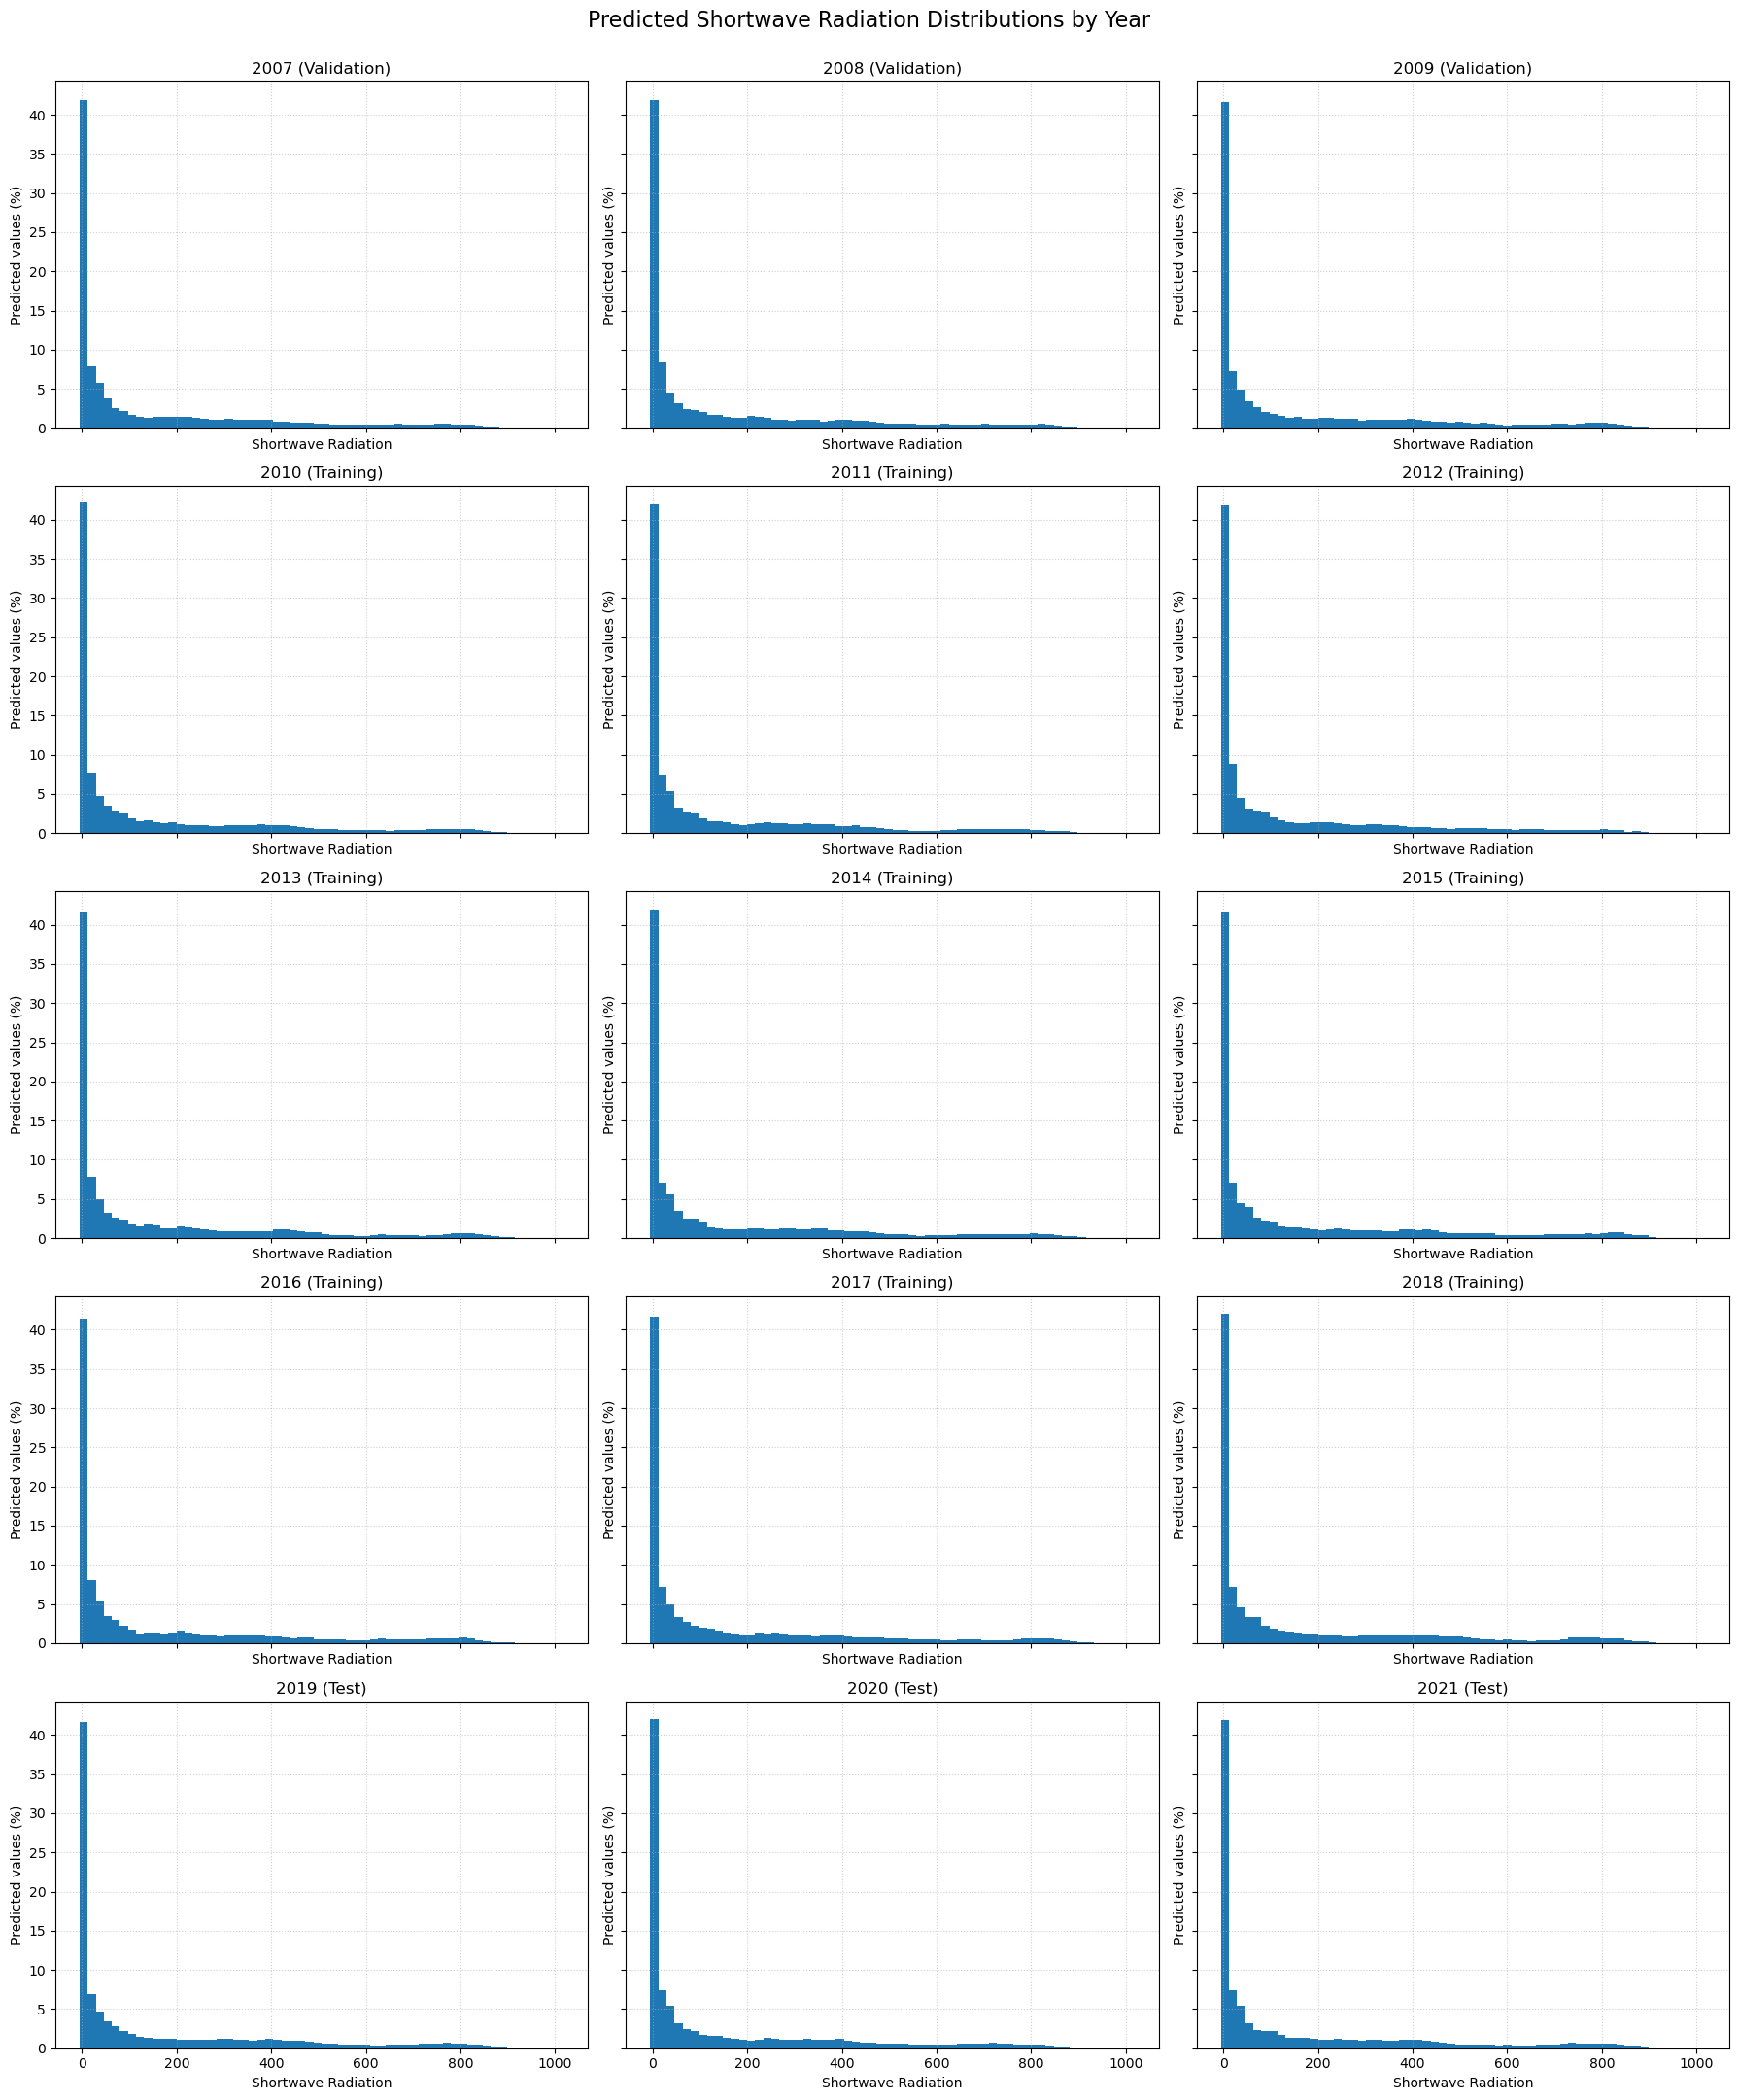

In [65]:
fig, axes = plt.subplots(5,3,figsize=(18,22),sharex=True,sharey=True)
axes = axes.ravel()

for ax, year in zip(axes,range(2007,2022)):
    year_split_name = None
    year_split_data = None

    for split_name, split_data in predicted_split_data.items():
        if year in split_data["years"]:
            year_split_name = split_name
            year_split_data = split_data
            break

    year_positions = np.where(year_split_data["times"].year == year)[0]

    if len(year_positions) == 0:
        ax.set_title(f"{year}: No data")
        continue

    year_predictions = year_split_data["values"][year_positions[0]:year_positions[-1] + 1]
    year_histogram_counts, _ = np.histogram(year_predictions,bins=histogram_bins)
    year_histogram_percentage = 100 * year_histogram_counts / year_histogram_counts.sum()

    ax.stairs(year_histogram_percentage,histogram_bins,fill=True)
    ax.set_title(f"{year} ({year_split_name})")
    ax.set_xlabel("Shortwave Radiation")
    ax.set_ylabel("Predicted values (%)")
    ax.grid(True, linestyle=':', alpha=0.6)

fig.suptitle("Predicted Shortwave Radiation Distributions by Year",fontsize=16)
plt.tight_layout(rect=[0,0,1,0.98])
plt.show()

Actual 2008 shape: (2920, 81383)
Predicted 2008 shape: (2920, 81383)
Number of 2008 timestamps: 2920
Number of selected spatial points: 16277
Mean RMSE across selected points: 84.76601
Minimum RMSE: 76.54551
Maximum RMSE: 92.9671


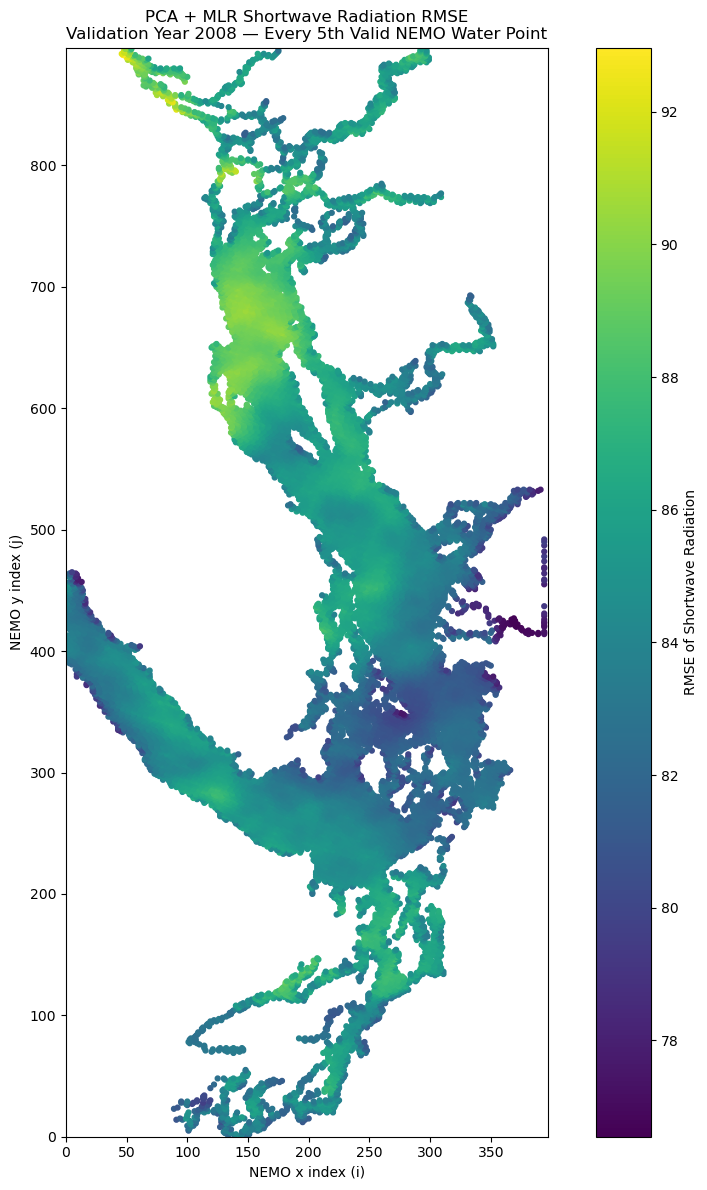

 Matrix_Column  NEMO_j  NEMO_i      RMSE
             0       1     134 81.550606
             5       1     139 82.917282
            10       1     144 84.761589
            15       1     149 82.166702
            20       2     133 82.104210
            25       2     140 84.452034
            30       2     145 84.148865
            35       2     151 82.239738
            40       3     131 82.547943
            45       3     136 83.958817
            50       3     145 83.663757
            55       3     150 83.033134
            60       4     130 83.320648
            65       4     135 84.236061
            70       4     145 83.233185
            75       4     150 83.653687
            80       5     101 81.491409
            85       5     133 83.863411
            90       5     147 84.081078
            95       5     152 83.687302


In [66]:
validation_year = 2008
spatial_step = 5

val_times = pd.to_datetime(ds_hrdps_val["time_counter"].values)
year_time_mask = val_times.year == validation_year

if not np.any(year_time_mask):
    raise ValueError(f"No validation data found for {validation_year}.")

X_actual_2008 = X_hrdps_val[year_time_mask]
X_predicted_2008 = X_hrdps_val_pred[year_time_mask]

print("Actual 2008 shape:", X_actual_2008.shape)
print("Predicted 2008 shape:", X_predicted_2008.shape)
print("Number of 2008 timestamps:", np.sum(year_time_mask))

if X_actual_2008.shape != X_predicted_2008.shape:
    raise ValueError("Actual and predicted validation matrices do not have matching shapes.")

selected_columns = np.arange(0, X_actual_2008.shape[1], spatial_step)

actual_selected = X_actual_2008[:, selected_columns]
predicted_selected = X_predicted_2008[:, selected_columns]

rmse_every_5th_point = np.sqrt(
    np.nanmean(
        (predicted_selected - actual_selected) ** 2,
        axis=0
    )
)

selected_nemo_j = valid_nemo_j[selected_columns]
selected_nemo_i = valid_nemo_i[selected_columns]

print("Number of selected spatial points:", len(selected_columns))
print("Mean RMSE across selected points:", np.nanmean(rmse_every_5th_point))
print("Minimum RMSE:", np.nanmin(rmse_every_5th_point))
print("Maximum RMSE:", np.nanmax(rmse_every_5th_point))

fig, ax = plt.subplots(figsize=(10, 12))

scatter = ax.scatter(
    selected_nemo_i,
    selected_nemo_j,
    c=rmse_every_5th_point,
    cmap="viridis",
    s=12,
    marker="o"
)

colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label("RMSE of Shortwave Radiation")

ax.set_xlabel("NEMO x index (i)")
ax.set_ylabel("NEMO y index (j)")
ax.set_title(
    "PCA + MLR Shortwave Radiation RMSE\n"
    "Validation Year 2008 — Every 5th Valid NEMO Water Point"
)

ax.set_xlim(0, water_mask.shape[1] - 1)
ax.set_ylim(0, water_mask.shape[0] - 1)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

rmse_every_5th_point_table = pd.DataFrame(
    {
        "Matrix_Column": selected_columns,
        "NEMO_j": selected_nemo_j,
        "NEMO_i": selected_nemo_i,
        "RMSE": rmse_every_5th_point
    }
)

print(rmse_every_5th_point_table.head(20).to_string(index=False))

In [67]:
output_directory = Path("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/predictions/pca_lr_predictions_2008")
output_directory.mkdir(parents=True, exist_ok=True)
solar_output_file = output_directory / "pred_solar_2008.nc"

In [68]:
solar_predictions = np.asarray(X_hrdps_val_pred,dtype=np.float32,)
validation_times_all = pd.DatetimeIndex(pd.to_datetime(ds_hrdps_val["time_counter"].values))
mask_2008 = validation_times_all.year == 2008
solar_predictions = solar_predictions[mask_2008]
validation_times = validation_times_all[mask_2008]
ny, nx = water_mask.shape
print("Predictions:", solar_predictions.shape)
print("NEMO grid:", ny, nx)
print("Validation times:", len(validation_times))

Predictions: (2920, 81383)
NEMO grid: 898 398
Validation times: 2920


In [69]:
assert solar_predictions.shape[0] == len(validation_times)
assert np.all(validation_times.year == 2008)
assert solar_predictions.shape[1] == len(valid_nemo_j)

print("First timestamp:", validation_times[0])
print("Last timestamp:", validation_times[-1])

First timestamp: 2008-01-01 00:00:00
Last timestamp: 2008-12-31 21:00:00


In [70]:
fill_value = np.float32(1e20)

with nc.Dataset(solar_output_file, mode="w", format="NETCDF4") as output_nc:

    # Dimensions
    output_nc.createDimension("time_counter", None)
    output_nc.createDimension("y", ny)
    output_nc.createDimension("x", nx)

    # Coordinate variables
    time_variable = output_nc.createVariable("time_counter", "f8", ("time_counter",))
    y_variable = output_nc.createVariable("y", "i4", ("y",))
    x_variable = output_nc.createVariable("x", "i4", ("x",))
    nav_lat_variable = output_nc.createVariable("nav_lat", "f4", ("y", "x"), zlib=True, complevel=4)
    nav_lon_variable = output_nc.createVariable("nav_lon", "f4", ("y", "x"), zlib=True, complevel=4)
    tmask_variable = output_nc.createVariable("tmask", "i1", ("y", "x"), zlib=True, complevel=4)

    # Shortwave radiation variable
    solar_variable = output_nc.createVariable("solar", "f4", ("time_counter", "y", "x"), fill_value=fill_value, zlib=True, complevel=4, shuffle=True, chunksizes=(8, min(200, ny), min(200, nx)))

    # Time metadata
    time_variable.units = "seconds since 1970-01-01 00:00:00"
    time_variable.calendar = "standard"
    time_variable.standard_name = "time"
    time_variable.long_name = "time"

    # Spatial-coordinate metadata
    nav_lat_variable.units = "degrees_north"
    nav_lat_variable.standard_name = "latitude"
    nav_lat_variable.long_name = "latitude"
    nav_lon_variable.units = "degrees_east"
    nav_lon_variable.standard_name = "longitude"
    nav_lon_variable.long_name = "longitude"
    tmask_variable.long_name = "NEMO surface water mask"
    tmask_variable.flag_values = np.array([0, 1], dtype=np.int8)
    tmask_variable.flag_meanings = "land water"

    # Solar metadata
    solar_variable.units = "W m-2"
    solar_variable.standard_name = "net_downward_shortwave_flux_in_air"
    solar_variable.long_name = "PCA and multiple linear regression downscaled shortwave radiation"
    solar_variable.coordinates = "time_counter nav_lat nav_lon"
    solar_variable.grid = "SalishSeaCast NEMO grid"
    solar_variable.prediction_method = "PCA plus multiple linear regression"

    # Global metadata
    output_nc.title = "PCA and linear regression downscaled shortwave radiation for 2008"
    output_nc.notebook_github_url = "https://github.com/SalishSeaCast/analysis-dishika/blob/main/notebooks/PCA_LR_All_Final/shortwave_radiation.ipynb"
    output_nc.data_split = "validation"
    output_nc.year = 2008
    output_nc.time_resolution = "3-hourly"
    output_nc.selected_hrdps_pcs = int(n_hrdps_pcs)
    output_nc.selected_canrcm_pcs = int(n_canrcm_pcs)
    output_nc.note = "Predictions are available at retained NEMO water cells. Land cells and excluded water cells contain the fill value."

    # Write coordinates
    y_variable[:] = np.arange(ny, dtype=np.int32)
    x_variable[:] = np.arange(nx, dtype=np.int32)
    nav_lat_variable[:, :] = nemo_lat_2d.astype(np.float32)
    nav_lon_variable[:, :] = nemo_lon_2d.astype(np.float32)
    tmask_variable[:, :] = water_mask.astype(np.int8)

    python_times = validation_times.to_pydatetime()
    time_variable[:] = nc.date2num(python_times, units=time_variable.units, calendar=time_variable.calendar)

    # Write eight 3-hourly predictions at a time
    number_of_times = solar_predictions.shape[0]
    batch_size = 8

    for start_index in range(0, number_of_times, batch_size):
        end_index = min(start_index + batch_size, number_of_times)
        current_batch_size = end_index - start_index
        full_grid_batch = np.full((current_batch_size, ny, nx), fill_value, dtype=np.float32)
        full_grid_batch[:, valid_nemo_j, valid_nemo_i] = solar_predictions[start_index:end_index]
        solar_variable[start_index:end_index, :, :] = full_grid_batch
        print(f"Written timestamps: {end_index}/{number_of_times}", end="\r")

print("\nShortwave Radiation file saved to:")
print(solar_output_file)

Written timestamps: 2920/2920
Shortwave Radiation file saved to:
/ocean/dtaneja/MOAD/analysis-dishika/notebooks/predictions/pca_lr_predictions_2008/pred_solar_2008.nc


In [71]:
ds_solar_check = xr.open_dataset(solar_output_file)

print(ds_solar_check)
print("Solar dimensions:", ds_solar_check["solar"].dims)
print("Solar shape:", ds_solar_check["solar"].shape)

ds_solar_check.close()

<xarray.Dataset> Size: 4GB
Dimensions:       (y: 898, x: 398, time_counter: 2920)
Coordinates:
  * y             (y) int32 4kB 0 1 2 3 4 5 6 7 ... 891 892 893 894 895 896 897
  * x             (x) int32 2kB 0 1 2 3 4 5 6 7 ... 391 392 393 394 395 396 397
    nav_lat       (y, x) float32 1MB ...
    nav_lon       (y, x) float32 1MB ...
  * time_counter  (time_counter) datetime64[ns] 23kB 2008-01-01 ... 2008-12-3...
Data variables:
    tmask         (y, x) int8 357kB ...
    solar         (time_counter, y, x) float32 4GB ...
Attributes:
    title:                PCA and linear regression downscaled shortwave radi...
    notebook_github_url:  https://github.com/SalishSeaCast/analysis-dishika/b...
    data_split:           validation
    year:                 2008
    time_resolution:      3-hourly
    selected_hrdps_pcs:   5
    selected_canrcm_pcs:  92
    note:                 Predictions are available at retained NEMO water ce...
Solar dimensions: ('time_counter', 'y', 'x')
Solar shape

In [72]:
first_solar_map = ds_solar_check["solar"].isel(time_counter=0).values

print(first_solar_map.shape)
print("Finite cells:", np.isfinite(first_solar_map).sum())
print("Minimum:", np.nanmin(first_solar_map))
print("Maximum:", np.nanmax(first_solar_map))

ds_solar_check.close()

(898, 398)
Finite cells: 81383
Minimum: 5.8343506
Maximum: 16.466873


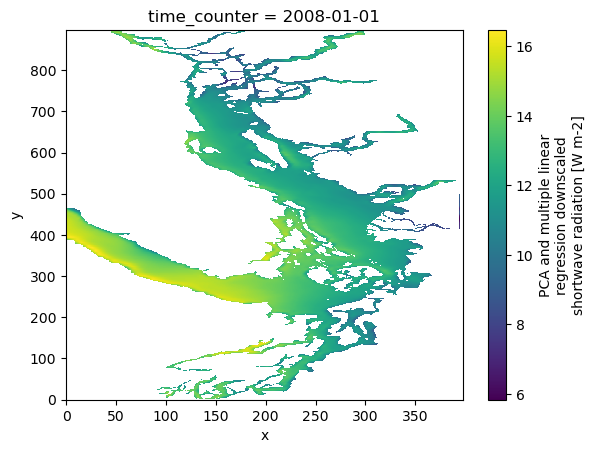

In [73]:
ds_solar_check["solar"].isel(time_counter=0).plot()

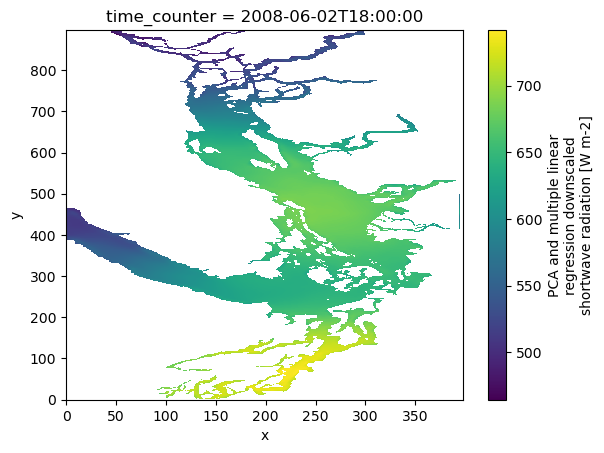

In [74]:
ds_solar_check["solar"].isel(time_counter=1222).plot()

In [75]:
print(ds_solar_check["time_counter"].values[0])
print(ds_solar_check["time_counter"].values[1])
print(ds_solar_check["time_counter"].values[2])
print(ds_solar_check["time_counter"].values[-2])
print(ds_solar_check["time_counter"].values[-1])

2008-01-01T00:00:00.000000000
2008-01-01T03:00:00.000000000
2008-01-01T06:00:00.000000000
2008-12-31T18:00:00.000000000
2008-12-31T21:00:00.000000000
